<a href="https://colab.research.google.com/github/Suhrobjonibodullayev/ML-Learning-Journey/blob/main/05_machine_learning_basics/Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Ai - odamlarga taqlid qiluvchi kamputerlar(dasturlar)

**Machine Learning (ML)** - Kamputerlarni dasturlamagan holda o'z o'zini o'qitish imkonini berish.

ML ishlatiladi:

• Ko'p qonun-qoidalar va shartlar yozishni talab qiladigan
muammolar

• Klassik usul bilan yechim topib bo'lmaydigan kompleks muammolar

• Doimiy o'zgaruvchan muammolar

• Katta o'Ichamdagi ma'lumotlardan yashirin mazmuni va ma'nolarni topishga oid muammolar

EDA — datasetni jadval, statistika va grafiklar orqali o'rganib, undagi tuzilma, muammo va bog'lanishlarni topish jarayoni. Maqsad — model qurishdan OLDIN ma'lumotni tushunish.

1.1 Jarayonni tushunish --> savollar berish orqali

1.2 Analitik yondashuv

1) Qaysi Ml turini tanlaymiz -> Supervised \ Unsupervised \ Reinforestment Learning

2) Muammo turi (Algoritm) -> Regression \ Classification \ Clastering

3) Usul -> online \ offline

Model aniqligini baholash

• MAE - Mean Absolute Error (O'rtacha absolyut xatolik)

• RMSE - Root Mean Square Error (O'rtacha kvadrat xatolik)

In [254]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from IPython.display import Image
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.svm import SVC, SVR
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, export_text, plot_tree
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    mean_absolute_error,
    median_absolute_error,
    mean_squared_error,
    r2_score,
    recall_score,
    precision_score,
    f1_score,
    roc_auc_score,
    jaccard_score
)

# Machine Learning Steps

### Malumotlarni o'rganish

In [255]:
# DataFrame bilan tanishuv
URL = "https://github.com/ageron/handson-ml2/blob/master/datasets/housing/housing.csv?raw=true"
df = pd.read_csv(URL)
df.head(7)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY


In [256]:
df.info() # Ustunlar va ularning dtype larini ko'rish mumkin | Nan qiymatlar bor yoki yo'qligini ko'rish mumkin

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [257]:
print(df['ocean_proximity'].value_counts()) # ustundagi takrorlanmas qiymatlarni ko'rish

df['ocean_proximity'].value_counts(normalize=True, sort=True, ascending=False, bins=None, dropna=True) # normilize true foizda qaytaradi.

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


,proportion
ocean_proximity,
<1H OCEAN,0.442636
INLAND,0.317393
NEAR OCEAN,0.128779
NEAR BAY,0.110950
ISLAND,0.000242


In [258]:
df.dtypes.value_counts() # malumot turlarining taqsimoti

,count
float64,9
object,1


In [259]:
df.select_dtypes(include="object") # object ustunlarni ajratadi, (np.number) numeric , (int, float)

,ocean_proximity
0,NEAR BAY
1,NEAR BAY
2,NEAR BAY
3,NEAR BAY
4,NEAR BAY
...,...
20635,INLAND
20636,INLAND
20637,INLAND
20638,INLAND


In [260]:
df.describe() # turli statistikalar | Naodatiy qiymatlar bor yo'qligini ko'rish mumkin -> min / max qiymatlar orqali

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [261]:
df.describe(include='object') # turli statistikalar | unique orqali ustundagi unique qiymatlar sonini ko'rish mumkin

,ocean_proximity
count,20640
unique,5
top,<1H OCEAN
freq,9136


In [262]:
df.duplicated().sum() # duplicatlar soni

df[df.duplicated(keep=False)].head(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity


In [263]:
print("Dataset:", df.shape)
print("Duplicates:", df.duplicated().sum())
print("Duplicate %:", round(df.duplicated().mean() * 100, 2))

Dataset: (20640, 10)
Duplicates: 0
Duplicate %: 0.0


In [264]:
df.drop_duplicates(inplace=True) # duplicatlarni olib tashlash

**Grafiklar** orqali malumotlarni tahlil qilish

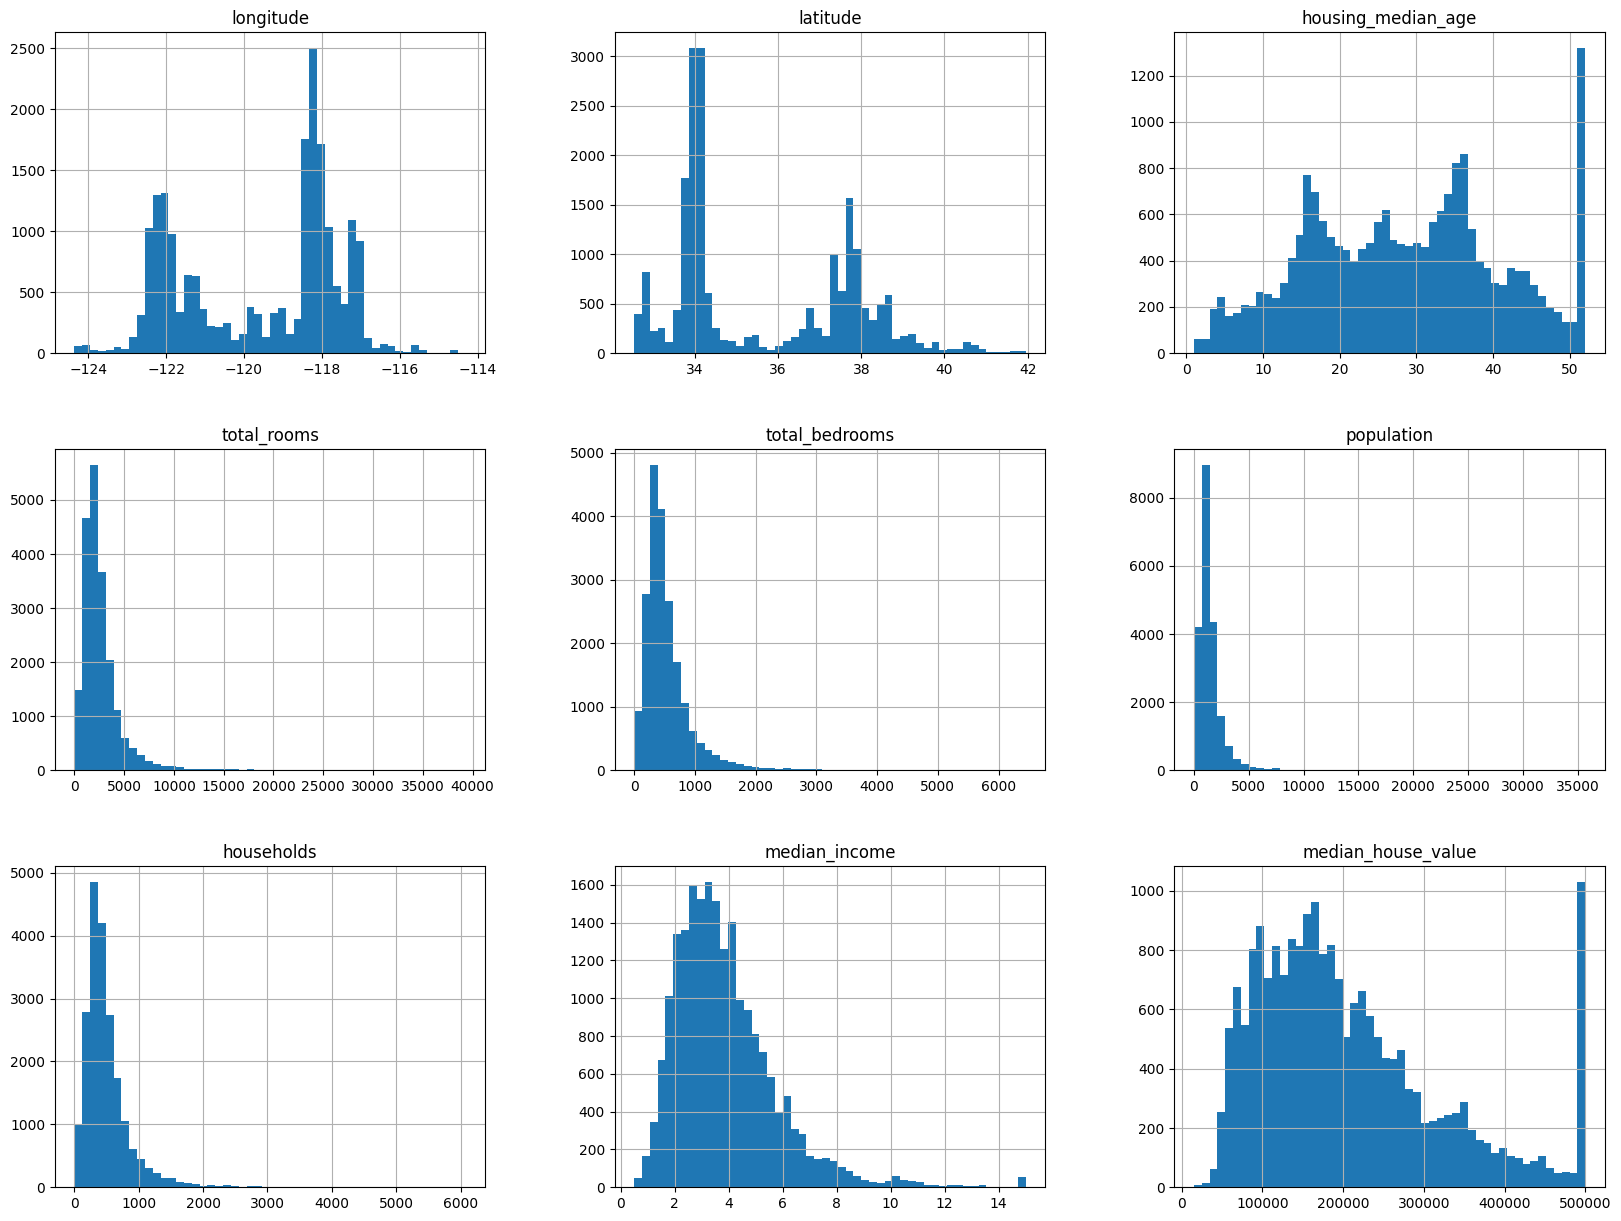

In [265]:
df.hist(bins=50, figsize=(20,15)) # turli xulosalar olish mumkin. | Naodatiy qiymatlar 'housing_median_age'
plt.show()

**Train \ Test \ Validayion** qismlarga ajratish

In [266]:
from sklearn.model_selection import train_test_split
train_set , test_set = train_test_split(df, test_size=0.2 , random_state=42)

Muvozanatli train / test ga ajratish | biror bir
ustun bo'yicha

In [267]:
df['income_cat'] = pd.cut(df['median_income'], bins=[0., 1.5, 3.0, 4.5, 6.0, np.inf], labels=[1,2,3,4,5]) # guruxlash

from sklearn.model_selection import StratifiedShuffleSplit
stratified_split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
# stratified_split.split funksiyasi indekslar qaytaradi
for train_index, test_index in stratified_split.split(df,df['income_cat']):
    strat_train_set = df.loc[train_index]
    strat_test_set = df.loc[test_index]

**Vizualziasiya**

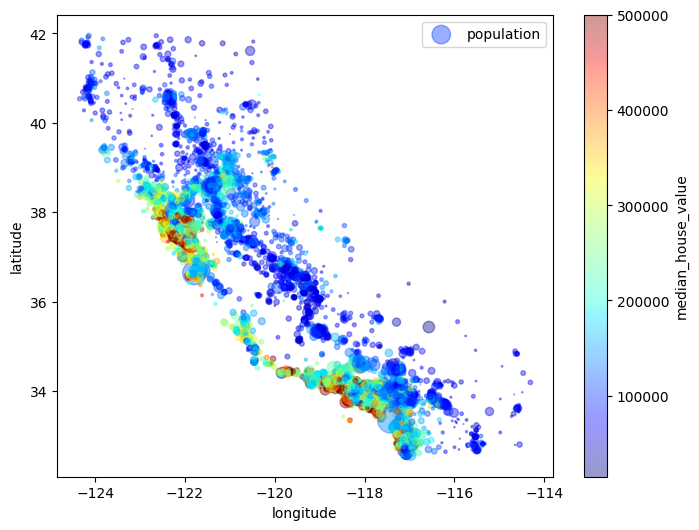

In [268]:
housing = train_set.copy()

housing.plot(
    kind="scatter",
    x="longitude",
    y="latitude",
    alpha=0.4,
    s=housing['population']/100, # nuqta radiusi aholi soniga qarab o'zgaradi
    label="population",
    c="median_house_value", # nuqta rangi uyning narxiga qarab o'zgaradi
    cmap="jet", # ranglar. Ko'k - daromadi kam, qizil - daromadi ko'p
    colorbar=True,
    figsize=(8,6)
)
plt.show()

# Okeanga yaqin joylarda uylarning ham narxi qimmatroq
# Okeanga yaqin hududlarda aholi zichroq

**Korrelyasiya**

In [269]:
housing_yield = housing['ocean_proximity']
housing.drop('ocean_proximity', axis=1 , inplace=True)

housing.corrwith(housing['median_house_value']).sort_values(ascending=False).head(4)

,0
median_house_value,1.000000
median_income,0.690647
total_rooms,0.133989
housing_median_age,0.103706


In [270]:
housing.corr(numeric_only=True)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924485,-0.101818,0.038676,0.063064,0.094276,0.049306,-0.017040,-0.046349
latitude,-0.924485,1.000000,0.005296,-0.029224,-0.059998,-0.102499,-0.064061,-0.076571,-0.142983
housing_median_age,-0.101818,0.005296,1.000000,-0.360922,-0.320624,-0.292283,-0.302796,-0.121711,0.103706
total_rooms,0.038676,-0.029224,-0.360922,1.000000,0.930489,0.857936,0.920482,0.198268,0.133989
total_bedrooms,0.063064,-0.059998,-0.320624,0.930489,1.000000,0.878932,0.980255,-0.009141,0.047980
population,0.094276,-0.102499,-0.292283,0.857936,0.878932,1.000000,0.907452,0.004122,-0.026032
households,0.049306,-0.064061,-0.302796,0.920482,0.980255,0.907452,1.000000,0.012776,0.063714
median_income,-0.017040,-0.076571,-0.121711,0.198268,-0.009141,0.004122,0.012776,1.000000,0.690647
median_house_value,-0.046349,-0.142983,0.103706,0.133989,0.047980,-0.026032,0.063714,0.690647,1.000000


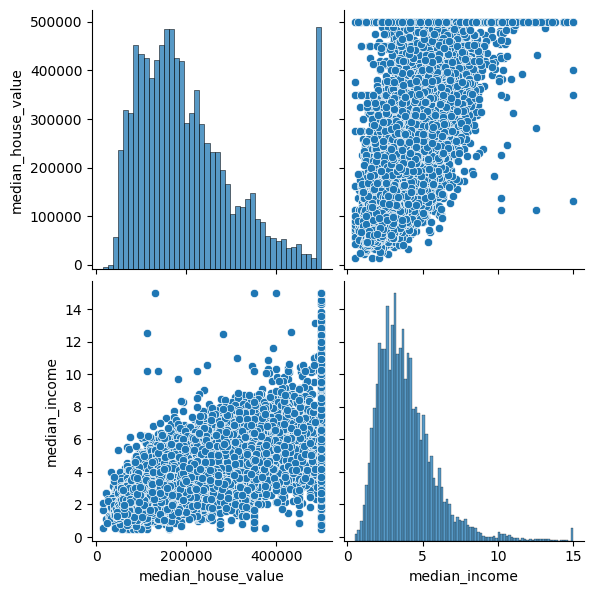

In [271]:
cols = ['median_house_value','median_income']
sns.pairplot(housing[cols], height=3) # juft qilib chiqaradi
plt.show()

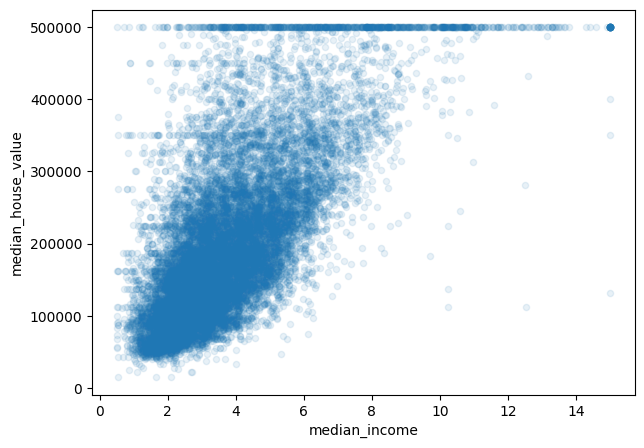

In [272]:
housing.plot(kind='scatter', x="median_income", y="median_house_value", alpha=0.1, figsize=(7,5))
plt.show()

**Yangi parametrlar yaratish**

In [273]:
housing["bedrooms_per_room"] = housing["total_bedrooms"]/housing["total_rooms"] # yangi ustun

housing.corrwith(housing['median_house_value']).sort_values(ascending=False) # manfiy bog'liklik

,0
median_house_value,1.000000
median_income,0.690647
total_rooms,0.133989
housing_median_age,0.103706
households,0.063714
total_bedrooms,0.047980
population,-0.026032
longitude,-0.046349
latitude,-0.142983
bedrooms_per_room,-0.257419


### Ma'lumotlarni Machine Learning uchun tayyorlash

In [274]:
URL = "https://github.com/ageron/handson-ml2/blob/master/datasets/housing/housing.csv?raw=true"
df = pd.read_csv(URL)

# train test setga ajratish
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)

#javobni ajratib olish
housing = train_set.drop("median_house_value", axis=1)
housing_labels = train_set["median_house_value"].copy()

**Tozalash**

In [275]:
# 1-variant. Qatorlarni tashlab yuborish
housing.dropna(subset=['total_bedrooms']) # inplace=True

# 2-variant. Ustunni tashlab yuborish
housing.drop("total_bedrooms", axis=1)

# 3-variant. Median qiymat bilan to'ldirish
median = housing["total_bedrooms"].median()
housing["total_bedrooms"].fillna(median)

,total_bedrooms
14196,627.0
8267,787.0
17445,331.0
14265,367.0
2271,431.0
...,...
11284,201.0
11964,570.0
5390,569.0
860,597.0


**SimpleImputer**

In [276]:
# SimpleImputer klassini chaqiramiz
from sklearn.impute import SimpleImputer
# SimpleImputer klassidan yangi obyekt yaratamiz va NaN qiymatlarni median qiymat bilan to'ldirishni ko'rsatamiz
imputer = SimpleImputer(strategy="median")

housing_num = housing.drop("ocean_proximity", axis=1) # matnli ustunlarni tashlab yuborish
imputer.fit(housing_num) # median qiymatlarni hisoblash
imputer.statistics_ # hisoblangan median qiymatlarni ko'rish
X = imputer.transform(housing_num) # hisoblangan median qiymatlar bilan to'ldirish

X = imputer.fit_transform(housing_num) # birdaniga bajarish

housing_tr = pd.DataFrame(X, columns=housing_num.columns, index=housing_num.index) # np.array dan Df ga o'tkazish

**Matnli ustunlarni shakl almashtirish**

In [277]:
housing_cat = housing[['ocean_proximity']]

from sklearn.preprocessing import OrdinalEncoder # 1- usul OrdinalEncoder -> Har bir matnni son bilan almashtirish.
ordinal_encoder = OrdinalEncoder()
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)

**OneHotEncoder** - usuli yordamida har bir noyob qiymat alohida ustunga aylanadi va mos keluvchi ustunga 1, qolganlariga 0 qo'yiladi


In [278]:
from sklearn.preprocessing import OneHotEncoder
cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
housing_cat_1hot.toarray()

# pd.get_dummies(housing['ocean_proximity']) # OneHotEncoder bilan bir xil vazifani bajaradi va DF qaytaradi

array([[0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1.],
       ...,
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0.]])

**3.3 Transfomer**

**Estimator** - tahmin qiluvchi (baholovchi) funksiyalar. Bunday obyektlar .fit() metodiga ega bo'ladi, bu metod berilgan ma'lumotlardan qandaydur qiymatni hisoblaydi.

**Transformer** - ham tahmin qilib ham ma'lumotga ishlov beruvchi obyekt. Bunday obyektlar .fit_transform() metodiga ega bo'ladi, ya'ni avval qandaydur qiymatnbi hisoblaydi, keyin esa hisoblashni ma'lumotlarga qo'llaydi.

**Predictor** - bashorat qiluvchi obyektlar. Bunday obyektlar .predict() metodiga ega bo'ladi. Ular biz bergan ma'lumotlar asosida bashoratlar qaytaradi.

In [279]:
from sklearn.base import BaseEstimator, TransformerMixin

# bizga kerak ustunlar indekslari
rooms_ix, bedrooms_ix, population_ix, households_ix = 3, 4, 5, 6

class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
    def __init__(self, add_bedrooms_per_room = True):
        self.add_bedrooms_per_room = add_bedrooms_per_room
    def fit(self, X, y=None):
        return self # bizni funksiyamiz faqat transformer. estimator emas
    def transform(self, X):
        rooms_per_household = X[:, rooms_ix] / X[:, households_ix]
        population_per_household = X[:, population_ix] / X[:, households_ix]
        if self.add_bedrooms_per_room: # add_bedrooms_per_room ustuni ixtiyoriy bo'ladi
            bedrooms_per_room = X[:, bedrooms_ix] / X[:, rooms_ix]
            return np.c_[X, rooms_per_household, population_per_household, bedrooms_per_room]
        else:
            return np.c_[X, rooms_per_household, population_per_household]

### 3.4 Standartizasiya va normalizasiya

In [280]:
# MinMaxScaler

from sklearn.preprocessing import MinMaxScaler
min_mix_scaler = MinMaxScaler()

min_mix_scaler.fit_transform(housing_num)

array([[0.72908367, 0.01702128, 0.62745098, ..., 0.06437961, 0.10228581,
        0.19032151],
       [0.61653386, 0.12978723, 0.94117647, ..., 0.0367443 , 0.12415721,
        0.22845202],
       [0.38545817, 0.22446809, 0.05882353, ..., 0.02556125, 0.05508962,
        0.25216204],
       ...,
       [0.59462151, 0.15744681, 0.68627451, ..., 0.04913254, 0.08649893,
        0.16789424],
       [0.23804781, 0.53510638, 0.2745098 , ..., 0.04972112, 0.09176122,
        0.35994676],
       [0.19223108, 0.55531915, 1.        , ..., 0.07332044, 0.20407828,
        0.14314285]])

In [281]:
# Standard Scaler - standartlash

from sklearn.preprocessing import StandardScaler
standart_scaler = StandardScaler()
standart_scaler.fit_transform(housing_num)

array([[ 1.27258656, -1.3728112 ,  0.34849025, ...,  0.76827628,
         0.32290591, -0.326196  ],
       [ 0.70916212, -0.87669601,  1.61811813, ..., -0.09890135,
         0.6720272 , -0.03584338],
       [-0.44760309, -0.46014647, -1.95271028, ..., -0.44981806,
        -0.43046109,  0.14470145],
       ...,
       [ 0.59946887, -0.75500738,  0.58654547, ...,  0.28983345,
         0.07090859, -0.49697313],
       [-1.18553953,  0.90651045, -1.07984112, ...,  0.30830275,
         0.15490769,  0.96545045],
       [-1.41489815,  0.99543676,  1.85617335, ...,  1.04883375,
         1.94776365, -0.68544764]])

### **Pipeline - konveyer**

In [282]:
import pandas as pd
import numpy as np
import sklearn # scikit-learn kutubxonasi

# Onlayn dataset joylashgan manzilini ko'rsatamiaz
URL = "https://github.com/ageron/handson-ml2/blob/master/datasets/housing/housing.csv?raw=true"
df = pd.read_csv(URL)

from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)

X_train = train_set.drop("median_house_value", axis=1)
y = train_set["median_house_value"].copy()

X_num = housing.drop("ocean_proximity", axis=1)

In [283]:
from sklearn.base import BaseEstimator, TransformerMixin
# bizga kerak ustunlar indekslari
rooms_ix, bedrooms_ix, population_ix, households_ix = 3, 4, 5, 6

class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
    def __init__(self, add_bedrooms_per_room = True):
        self.add_bedrooms_per_room = add_bedrooms_per_room
    def fit(self, X, y=None):
        return self # bizni funksiyamiz faqat transformer. estimator emas
    def transform(self, X):
        rooms_per_household = X[:, rooms_ix] / X[:, households_ix]
        population_per_household = X[:, population_ix] / X[:, households_ix]
        if self.add_bedrooms_per_room: # add_bedrooms_per_room ustuni ixtiyoriy bo'ladi
            bedrooms_per_room = X[:, bedrooms_ix] / X[:, rooms_ix]
            return np.c_[X, rooms_per_household, population_per_household, bedrooms_per_room]
        else:
            return np.c_[X, rooms_per_household, population_per_household]

Pipeline yaratamiz

In [284]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# sonlar bilan ishlovchi pipeline

num_pipeline = Pipeline([
          ('imputer', SimpleImputer(strategy='median')),
          ('attribs_adder', CombinedAttributesAdder(add_bedrooms_per_room = True)),
          ('std_scaler', StandardScaler())
])

In [285]:
from sklearn.compose import ColumnTransformer

num_attribs = list(X_num)
cat_attribs = ['ocean_proximity']

full_pipeline = ColumnTransformer([
    ('num', num_pipeline, num_attribs),
    ('cat', OneHotEncoder(), cat_attribs)
])

X_prepared = full_pipeline.fit_transform(X_train)

### **Linear Regression - Chiziqli regressiya**

In [286]:
from sklearn.linear_model import LinearRegression

LR_model = LinearRegression()

LR_model.fit(X_prepared, y)

LinearRegression()

In [287]:
from sklearn.linear_model import LinearRegression

# Re-initialize and re-fit LR_model with the full pipeline data
LR_model = LinearRegression()
LR_model.fit(X_prepared, y)

# tasodifiy 5 ta qatorni ajratib olamiz
test_data = X_train.sample(5)
# yuqoridagi qatorlarga mos keluvchi narxlarni ajratib olamiz (biz aynan shu qiymatlarni bashorat qilishimiz kerak)
test_label = y.loc[test_data.index]
# pipelinedan o'tkazish
test_data_prepared = full_pipeline.transform(test_data)
# predict qilish
predicted_data = LR_model.predict(test_data_prepared)

pd.DataFrame({'Prognoz':predicted_data, 'Asl baxosi': test_label, "Farq": predicted_data - test_label })

,Prognoz,Asl baxosi,Farq
10073,97700.126044,117300.0,-19599.873956
15449,237695.716772,182600.0,55095.716772
11380,267902.873654,239200.0,28702.873654
19578,115844.920469,143600.0,-27755.079531
3646,188959.775213,183700.0,5259.775213


### 5-QADAM. **Modelni baholaymiz**

In [288]:
X_test = test_set.drop('median_house_value', axis=1)
y_test = test_set['median_house_value'].copy()

X_test_prepared = full_pipeline.transform(X_test)

y_predicted = LR_model.predict(X_test_prepared)

In [289]:
def evaluate(model, X_tr, X_te, y_tr, y_te):
    p_tr = model.predict(X_tr)
    p_te = model.predict(X_te)
    return {
      "MAE"   : mean_absolute_error(y_te, p_te),
      "MedAE" : median_absolute_error(y_te, p_te),
      "RMSE"  : np.sqrt(mean_squared_error(y_te, p_te)),
      "R2_test" : r2_score(y_te, p_te),
      "R2_train": r2_score(y_tr, p_tr),
    }

res = evaluate(LR_model, X_prepared, X_test_prepared, y, y_test)
print(pd.Series(res).round(4))

MAE         50898.7395
MedAE       37952.1133
RMSE        72701.3260
R2_test         0.5967
R2_train        0.6582
dtype: float64


**Cross-Validation** usuli bilan baholash.

Cross validation uchun ma'lumotlarni train va testga bo'lish shart emas, buni sklearn o'zi qiladi.

In [290]:
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"].copy()

X_prepared = full_pipeline.transform(X)

def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Std.dev:", scores.std())

display_scores(scores)

Scores: [-7.08770558e+09 -3.74510262e+09 -7.52595175e+09 -3.87993733e+09
 -6.48675610e+09 -4.74988363e+09 -2.75665210e+09 -8.26464244e+09
 -6.03335515e+09 -2.90969679e+09]
Mean: -5343968348.43817
Std.dev: 1891713633.2377543


In [291]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(LR_model, X_prepared, y, scoring="neg_mean_squared_error", cv=10)
LR_rmse_scores = np.sqrt(-scores)

display_scores(LR_rmse_scores)

Scores: [84188.51219065 61197.24357613 86752.24346334 62289.14292385
 80540.40041898 68919.39949642 52503.82940087 90910.07884989
 77674.67507925 53941.60539478]
Mean: 71891.71307941683
Std.dev: 13249.525989444986


### **Modelni saqlash**

**pickle** yordamida saqlash

In [292]:
import pickle

filename = 'LR_model.pkl' # faylga istalgan nom beramiz
with open(filename, 'wb') as file:
    pickle.dump(LR_model, file)

In [293]:
with open(filename, 'rb') as file: # modelni o'qish
    model = pickle.load(file)

joblib yordamida saqlash

In [294]:
import joblib

filename = 'LR_model.jbl' # faylga istalgan nom beramiz
joblib.dump(LR_model, filename)

filename = 'pipeline.jbl'
joblib.dump(full_pipeline, filename) # pipeline saqlash

['pipeline.jbl']

In [295]:
model = joblib.load(filename) # modelni o'qish

# Supervised Learning

Supervised Learning (Nazorat ostida)

Regressiya (o'garuvchilar o'rtasida bog'liqlik)

• Bashorat (prognoz): iqlim, narx-navo, aholi soni, dollar kursi va hokazo

• Baholash: parametrlarga qarab uy, mashina, yerni baholash

Klassifikasiya

• Diagnostika

• Tasvirlarni ajratish

• Firibgarlikni aniqlash

• Mijozlarni saqlab qolish

Simple Regression -> Simple Linear Regression \ Simple non-Linear Regression

Multiple Regression -> Simple Multiple Regression \ Simple non-Multiple Regression

## **Regression**

### **Linear Regression**

In [296]:
df = pd.read_csv('https://raw.githubusercontent.com/anvarnarz/praktikum_datasets/main/housing_LR.csv', index_col=0)

housing = df[df.district=='Чиланзарский']

X = housing['size'].to_numpy()
y = housing['price'].to_numpy()

Size va Price ustunlari orasidagi bog'liqlikni grafikga ko'ramiz

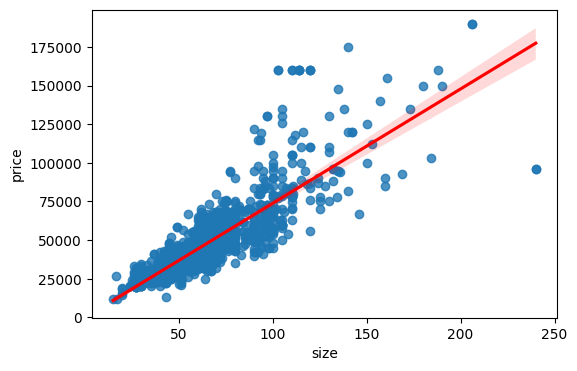

In [297]:
plt.figure(figsize=(6,4))
sns.regplot(data=housing, x='size', y='price', line_kws={"color": "red"})
plt.show()

Linear regression formulasidagi theta1 va theta0 ni hisoblash

In [298]:
import numpy as np

Xmean = np.mean(X)
ymean = np.mean(y)

theta1 = sum((X-Xmean)*(y-ymean))/sum((X-Xmean)**2)
print(f"{theta1=}")

theta0 = ymean - theta1*Xmean
print(f"{theta0=}")

theta1=np.float64(740.0264822713287)
theta0=np.float64(-195.94911352690542)


In [299]:
x_test = housing.sample(10, random_state=42)['size'].to_numpy()
print(f"{x_test=}")
y_test = housing.sample(10, random_state=42)['price'].to_numpy()
print(f"{y_test=}")

y_predict = theta0 + theta1*x_test
print(f"{y_predict=}")

x_test=array([54., 42., 36., 60., 48., 68., 38., 65., 52., 44.])
y_test=array([37500., 26500., 25500., 39000., 32500., 34500., 22700., 47000.,
       37900., 36000.])
y_predict=array([39765.48092912, 30885.16314187, 26445.00424824, 44205.63982275,
       35325.3220355 , 50125.85168092, 27925.05721278, 47905.77223411,
       38285.42796458, 32365.21610641])


MSE (root mean square error), MAE (mean absolute error)

In [300]:
# MAE
MAE = np.sum(np.absolute(y_predict-y_test))/len(y_test)
print(f"{MAE=}")

# RMSE
RMSE = np.sqrt(np.sum((y_predict-y_test)**2)/len(y_test))
print(f"{RMSE=}")

MAE=np.float64(4140.35031634715)
RMSE=np.float64(5882.051673173715)


### **Scikit-learn yordamida LR**

In [301]:
# train / test

from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(housing, test_size=0.10, random_state=42)

from sklearn import linear_model
LR_model = linear_model.LinearRegression()

x_train = np.asanyarray(train_set[['size']])
y_train = np.asanyarray(train_set[['price']])

# Modelni tarbiyalaymiz (train)
LR_model.fit(x_train, y_train)

#theta1 va theta0 koeefisentlarni ajratib olamiz
theta1 = LR_model.coef_[0][0]
theta0 = LR_model.intercept_[0]
print (f'{theta1=}')
print (f'{theta0=}')

LR_model.score(x_train, y_train)
LR_model.coef_ # w
LR_model.intercept_ # b

theta1=np.float64(732.7784051414766)
theta0=np.float64(106.31843170110369)


array([106.3184317])

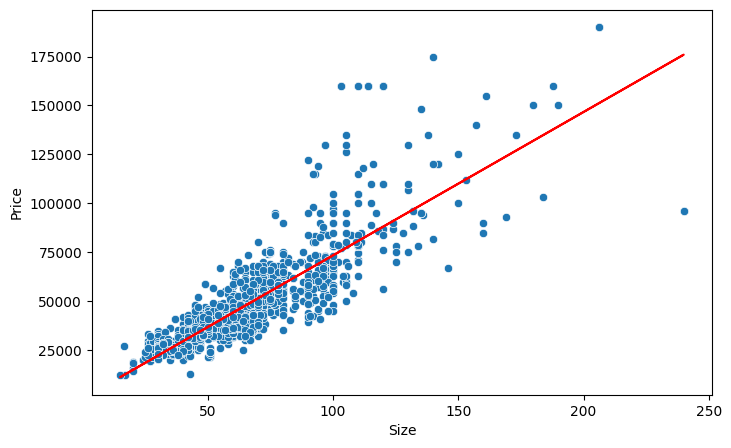

In [302]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=housing, x='size', y='price')
plt.plot(x_train, theta1*x_train + theta0, '-r')
plt.xlabel("Size")
plt.ylabel("Price")
plt.show()

Modelni baholash

In [303]:
x_test = np.asanyarray(test_set[['size']])
y_test = np.asanyarray(test_set[['price']])

y_predict = LR_model.predict(x_test)

In [304]:
def baholash(y_test,pred):
    MAE = np.sum(np.absolute(pred-y_test))/len(y_test)
    RMSE = np.sqrt(np.sum((pred-y_test)**2)/len(y_test))
    return MAE, RMSE

MAE, RMSE = baholash(y_test,y_predict)
print(f"{MAE=}")
print(f"{RMSE=}")

MAE=np.float64(7269.709648262382)
RMSE=np.float64(12734.803748258666)


RMSE har doim MAE dan katta yoki teng. Ular orasidagi farq katta bo'lsa — bir nechta juda katta xato bor.


In [305]:
# targetni log qilish natijani yaxshilashi kerak

y_log = np.log(y_train)
LR_model.fit(x_train, y_log)

# Bashoratni dollarga qaytarish
pred = np.exp(LR_model.predict(x_test))

In [306]:
MAE, RMSE = baholash(y_test,pred)
print(f"{MAE=}")
print(f"{RMSE=}")

MAE=np.float64(7410.409768703914)
RMSE=np.float64(13409.65536197421)


Natija 4 xil bo'ladi

1. nuqtalar chiziq atorfida joylashgan bu narmal
2. egri chiziq , parabolă model noto'g'ri tanlangan
3. 1 -2 nuqta ajralib chiziqni tortib tursa outlierlar bor
4. varonka shaklida Tarqoqlik o'ngga qarab
kengayadi., YECHIM: log(y) transform.

Agar model arzon uylarda kam, qimmat uylarda ko'p adashsa — qoldiqlar tarqoqligi bir xil emas.
Buni ko'z bilan ko'rish mumkin, lekin son bilan o'lchash ishonchliroq.

| Metric | Formula                       | Qoidasi                                                                 | Yaxshi natija |                          |             |
| ------ | ----------------------------- | ----------------------------------------------------------------------- | ------------- | ------------------------ | ----------- |
| MAE    | $\frac{1}{n}\sum|y-\hat y|$   | Xatolarning mutlaq qiymatlari o‘rtachasi                                | 0 ga yaqin    |                          |             |
| MSE    | $\frac{1}{n}\sum(y-\hat y)^2$ | Xatolar kvadratining o‘rtachasi                                         | 0 ga yaqin    |                          |             |
| R²     | $1-\frac{SS_{res}}{SS_{tot}}$ | Model target variatsiyasining qancha qismini tushuntirishini ko‘rsatadi | 1 ga yaqin    |                          |             |
| MAPE   | $\frac{100}{n}\sum\left       | \frac{y-\hat y}{y}\right                                                | $             | Xatoni foizda ko‘rsatadi | 0% ga yaqin |
| MedAE  | $median(|y-\hat y|)$          | Xatolarning median qiymati                                              | 0 ga yaqin    |                          |             |


| Metric | Outlier ta'siri | Asosiy ma'nosi                                  |
| ------ | --------------- | ----------------------------------------------- |
| MAE    | O‘rtacha        | Model o‘rtacha nechaga xato qilmoqda?           |
| MSE    | Juda kuchli     | Katta xatolarni kuchli jazolaydi                |
| R²     | O‘rtacha        | Model targetni qanchalik yaxshi tushuntiryapti? |
| MAPE   | O‘rtacha        | O‘rtacha necha foiz xato?                       |
| MedAE  | Juda kam        | Odatdagi xatoni outlierlarsiz ko‘rsatadi        |


R² ga keraksiz feature qo‘shsangiz, R² odatda kamaymaydi. oshadi.

Adjusted R² Feature qo‘shish foydali bo‘lmasa, kamayishi mumkin


### **Multiple Linear Regression**

Ishlatilishi:

Qaysi parametrlar muhimligini aniqlash

Parametlar o'zgarishining tasirini aniqlash uchun

In [307]:
import pandas as pd
import numpy as np
df = pd.read_csv('https://raw.githubusercontent.com/anvarnarz/praktikum_datasets/main/housing_LR.csv', index_col=0)

housing = df[df.district=='Чиланзарский']
housing.head()

# train/test
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(housing, test_size=0.10, random_state=42)

from sklearn import linear_model
MLR_model = linear_model.LinearRegression()

# x_train = np.asanyarray(train_set[['rooms','size','level','max_levels']])
x_train = np.asanyarray(train_set[['size','max_levels']]) # bir nechta ustun olinsa bu Multiple LR
y_train = np.asanyarray(train_set[['price']])
MLR_model.fit (x_train, y_train)

# Koeffisientlar (theta1, theta2, ...)
print('Coefficients: ', MLR_model.coef_)
print('theta0:', MLR_model.intercept_)

Coefficients:  [[ 747.04795007 -393.4032521 ]]
theta0: [1341.57534414]


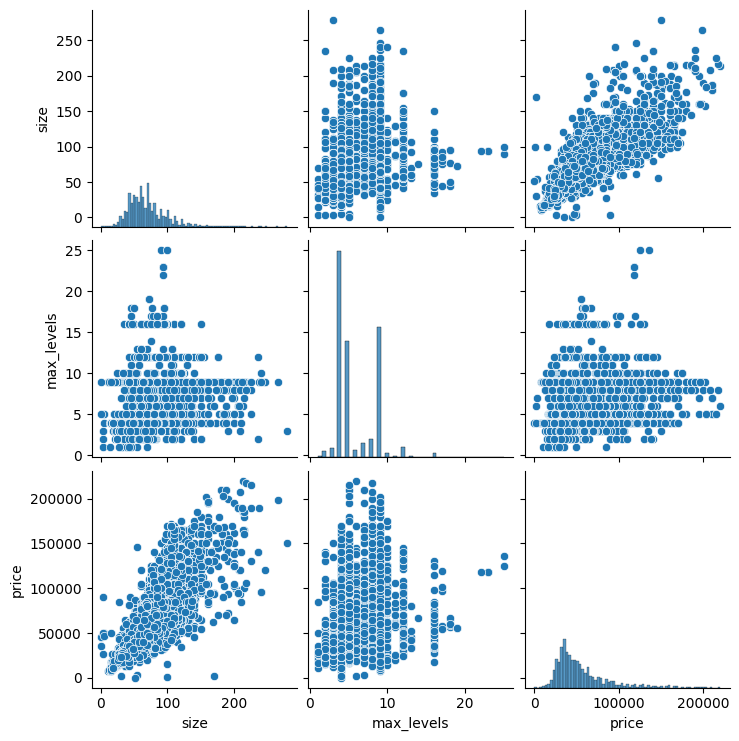

In [308]:
sns.pairplot(df[['size','max_levels','price']]) # bog'liqlikni ko'rish uchun grafik
plt.show()

In [309]:
# x_test = np.asanyarray(test_set[['rooms','size','level','max_levels']])
x_test = np.asanyarray(test_set[['size','max_levels']])
y_test = np.asanyarray(test_set[['price']])
y_predict = MLR_model.predict(x_test)

In [310]:
MAE = mean_absolute_error(y_test, y_predict)
RMSE = np.sqrt(mean_squared_error(y_test, y_predict))
print(f"{MAE=}")
print(f"{RMSE=}")

MAE=7193.9223780657785
RMSE=np.float64(12635.660248895361)


### **Polynomial Regression**

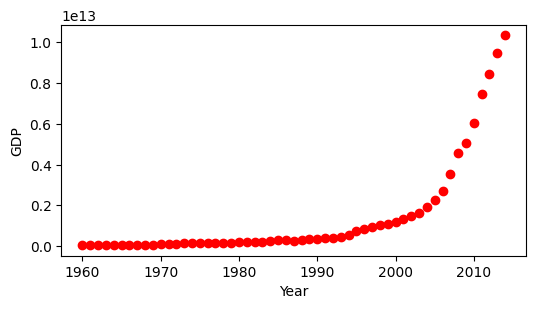

In [311]:
url="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/china_gdp.csv"

df = pd.read_csv(url)

plt.figure(figsize=(6,3))
x_data, y_data = (df["Year"].values, df["Value"].values)
plt.plot(x_data, y_data, 'ro')
plt.ylabel('GDP')
plt.xlabel('Year')
plt.show()

In [312]:
# Normalisatsiya
X = np.asanyarray(df[['Year']]/df.Year.max())
y = np.asanyarray(df[['Value']]/df.Value.max())

poly_features = PolynomialFeatures(degree=5, include_bias=False)
X_poly = poly_features.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)

yhat = model.predict(X_poly)

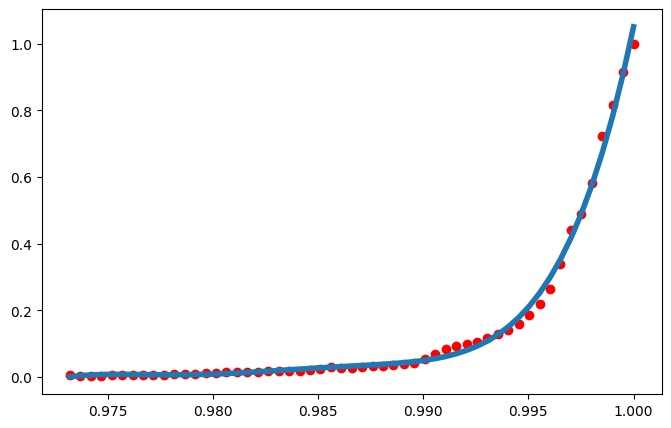

In [313]:
plt.figure(figsize=(8,5))
plt.plot(X, y, 'ro', label='data')
plt.plot(X,yhat, linewidth=4.0, label='fit')
plt.show()

In [314]:
print("MAE:", mean_absolute_error(yhat,y))

MAE: 0.009253921906050316


curve_fit yordamida o'zimiz yozgan funksiyalar asosida model qurishimiz mumkin.

In [315]:
# Saqlangan rasmni ochish
from IPython.display import Image
Image(url='https://miro.medium.com/v2/resize:fit:1046/1*l59BUnPwWHMf1H-GNxgZHQ.png',height=100)

# Sigmoid/ Logistic Regression formula

In [316]:
x_data, y_data = (df["Year"].values, df["Value"].values)
xdata =x_data/max(x_data)
ydata =y_data/max(y_data)

def sigmoid(x, Beta_1, Beta_2):
     y = 1 / (1 + np.exp(-Beta_1*(x-Beta_2)))
     return y

from scipy.optimize import curve_fit

beta, pcov = curve_fit(sigmoid, xdata, ydata)
print(f"beta1={beta[0]}\nbeta2={beta[1]}")

beta1=690.4517083847173
beta2=0.9972071272536834


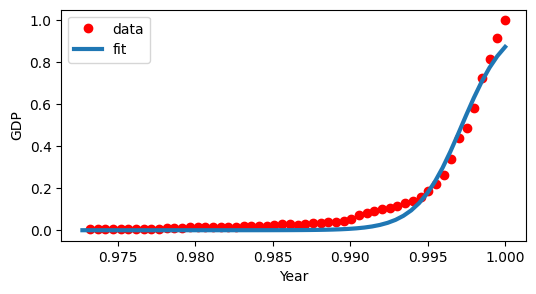

In [317]:
x = np.linspace(1960, 2015, 55)
x = x/max(x)
plt.figure(figsize=(6,3))
yhat = sigmoid(x, *beta)
plt.plot(xdata, ydata, 'ro', label='data')
plt.plot(x,yhat, linewidth=3.0, label='fit')
plt.legend(loc='best')
plt.ylabel('GDP')
plt.xlabel('Year')
plt.show()

In [318]:
print("MAE:", mean_absolute_error(yhat,ydata))

MAE: 0.030498418817641204


**Non-Linear Regression formulas**

In [319]:
Image(url='https://i.ytimg.com/vi/rb_IXh6aBK0/hqdefault.jpg')

### Overfitting / Underfitting

Underfitting -> Model juda sodda . Train setda ham test setda ham katta xatolik.

High bias (gumon)

Overfitting --> Model juda murakkab . Train setga moslashib qolgan. -> Train setda aniqlik baland (xato kam) , Test setda aniqlik juda ham past (xato ko'p)

High variance (farq)

Yaxshi model-> Train va Test setlarda birdek katta aniqlik

Low bias , low variance

Underfitting -> Modelni murakkablashtirish kerak.

1. Ko'proq parametrlar qo'shish
2. Polynomial darajani oshirish
3. Ko'proq qavatlar qo'shish(Deep learning)

Overfitting -> Modelni soddalashtirish kerak

1. Parametlarni kamaytirish
2. Algorithm ni o'zgartirish
3. Polynomial darajani kamaytirish
3. Ko'proq malumot yig'ish

In [320]:
Image(url="https://miro.medium.com/v2/resize:fit:1125/1*_7OPgojau8hkiPUiHoGK_w.png", height=200)

## **Classification**

**Classification** - Nomalum elementlarni kategoriyalarga (class) larga ajratish.

Ishlatilishi:

1. MIjozlarni kategoriyalarga ajratish
2. MIjoz qaytish yoki qaytmasligi (Customer churn)
3. Biror reklama mijozga to'g'ri kelish kelmasligi(targeted marketing)
4. Objectlarni aniqlsh , ajratish
5. Yuzni tanish(Face Id)
6. Qo'l yozma va Nutqni tushunish
7. Tavsiya tizimlari

In [321]:
from IPython.display import Image
# classification algorithms
Image(url='https://miro.medium.com/v2/resize:fit:1200/1*R6Rbcks-pGO0SkhCINrP0g.png', height=600)

**Logistic Regression**

Afzalligi -- Ehtimollikka asoslangan, har bir parameter muhimligini ham ko'rsatadi
Kamchiligi --Ustunlar o'rtasida logistic bog'liqlikni talab qiladi

**K-NN**

Afzalligi -- Sodda, tez va samarali

Kamchiligi -- K-qiymatini to'g'ri topish kerak

**Support Vector Machine (SVM)**

Afzalligi -- Samarali, noodatiy qiymatlarga sezgir emas, overfitting oldini oladi

Kamchiligi -- Ko'p ustunli (parametrli) datasetlarga to'g'ri kelmaydi. Chiziqli bo'lmagan muammolarga tushmaydi

**Kernel SVM**

Afzalligi-- Chizigli bo'Imagan muammolar uchun

Kamchiligi-- Ko'p ustunli (parametrli) datasetlarga to 'g'ri kelmaydi.

Decision Tree

Afzalligi -- Tushunishga oson, parametrlarga ishlov berish talab qilinmaydi, chiziqli va chiziqli bo'lmagan muammolarga birdek tushadi

Kamchiligi -- Kichik datasetlarda overfitting yuzaga keladi.

Random Forest

Afzalligi -- Aniqligi baland. Turli muammolarda yaxshi natija.

Kamchiligi -- Tushunishga qiyin, tarkibidagi daraxtlar sonini aniqlash kerak, overfittinga moyil

In [322]:
# classification algorithms
Image(url='https://miro.medium.com/v2/resize:fit:1080/1*p71ftGT0uRExSsmqCJ6-YA.jpeg',height=600)

### Logistic Regression

In [394]:
df = pd.read_csv("https://raw.githubusercontent.com/asrorKholmatov/ML_lesson_Datasets/refs/heads/main/kredit.csv")
df.head()

,yosh,oylik_daromad,ish_stazhi_yil,oldingi_kreditlar_soni,kredit_summasi,toladimi
0,30,1500000,3,0,18996154,0
1,21,3054979,0,3,14550517,0
2,19,2269501,1,1,17908133,0
3,19,5458185,1,1,13519034,0
4,32,6080301,6,3,8999869,0


In [399]:
Logistic = LogisticRegression(max_iter=1000, penalty='l2', solver='lbfgs', random_state=42)

X = df.drop("toladimi", axis=1)
y = df["toladimi"]

X_train, X_test, y_train, y_test = train_test_split(X , y , test_size=0.2,random_state=42, stratify=y)

Logistic.fit(X_train, y_train)

pred= Logistic.predict(X_test)

Accuracy: 0.88
Precision: 0.0
Recall: 0.0
F1 score: 0.0
ROC AUC score: 0.4888888888888889
              precision    recall  f1-score   support

           0       0.90      0.98      0.94        90
           1       0.00      0.00      0.00        10

    accuracy                           0.88       100
   macro avg       0.45      0.49      0.47       100
weighted avg       0.81      0.88      0.84       100



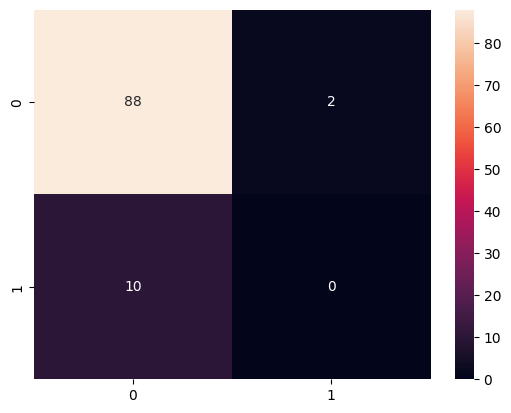

In [402]:
def acc(y_true, y_pred):
    print( 'Accuracy:', accuracy_score(y_true, y_pred, normalize=True))
    print( 'Precision:', precision_score(y_true, y_pred))
    print( 'Recall:', recall_score(y_true, y_pred))
    print( 'F1 score:', f1_score(y_true, y_pred))
    print( 'ROC AUC score:', roc_auc_score(y_true, y_pred))
    print(classification_report(y_true, y_pred))
    sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d')
    plt.show()

acc(y_test,pred)

### **KNN** - K-nearest neighbor-> k ta eng yaqin qo'shnilar

Nochiziqli chegarani osongina topadi. Farazlar yo'q. Bashorat sekin. Ustun ko'paysa aniqlik qulaydi.

sklearn.neighbors.KNeighborsClassifier(n_neighbors=5, *, weights='uniform', algorithm='auto', leaf_size=30, p=2, metric='minkowski', metric_params=None, n_jobs=None)

sklearn.neighbors.KNeighborsClassifier - bu sklearn kutubxonasi orqali taklif etilgan K-nearest neighbors (KNN) klassifikatori. U haqiqiy qiymatlar (sinfikatsiya maqsadida) uchun eng yaqin qo'shilgan n ta namunalarning kuchli "ko'rsatkichlari"ni hisoblash uchun ishlatiladi. Bu klassifikator yaxshi qilib ko'rsatilgan.

leaf_size: KD-derevo yoki ball agaci algoritmlarining barglari (integer, default=30). Ushbu parametr, izlash jarayonini tezlashtirish uchun belgilangan barglar sonini belgilaydi.

p: Masofa miqdori (integer, default=2). Ushbu parametr, masofa metrikasini aniqlaydi. Agar p=1 bo'lsa, masofa metrikasi manhattan masofasi (l1), agar p=2 bo'lsa, masofa metrikasi euclidean masofasi (l2) hisoblanadi.

metric: Masofa metrikasi (string, default='minkowski'). Ushbu parametr, qo'shilganlar orasidagi masofani hisoblash uchun foydalaniladigan metrikani belgilaydi.


In [323]:
url="https://raw.githubusercontent.com/anvarnarz/praktikum_datasets/main/breast-cancer.csv"
df = pd.read_csv(url)

# Harfli qiymatlarni songa o'zgartirish uchun sklearn tarkibidagi LabelEncoder dan yoki pandas dagi .replace() metodidan foydalanish mumkin.

labelencoder = LabelEncoder()

df['diagnosis'] = labelencoder.fit_transform(df['diagnosis'].values)
# df['diagnosis'] = df['diagnosis'].replace("M",1)
# df['diagnosis'] = df['diagnosis'].replace("B",0)
df['diagnosis'].value_counts()

,count
diagnosis,
0,357
1,212


In [324]:
# df.drop(columns=['id'], inplace=True)

corr_matrix = df.corr().abs().sort_values(by='diagnosis', ascending=False).head(8)
corr_matrix.style.background_gradient(cmap='Blues')

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
diagnosis,0.039769,1.000000,0.730029,0.415185,0.742636,0.708984,0.358560,0.596534,0.696360,0.776614,0.330499,0.012838,0.567134,0.008303,0.556141,0.548236,0.067016,0.292999,0.253730,0.408042,0.006522,0.077972,0.776454,0.456903,0.782914,0.733825,0.421465,0.590998,0.659610,0.793566,0.416294,0.323872
concave points_worst,0.035174,0.793566,0.744214,0.295316,0.771241,0.722017,0.503053,0.815573,0.861323,0.910155,0.430297,0.175325,0.531062,0.119638,0.554897,0.538166,0.102007,0.483208,0.440472,0.602450,0.030413,0.215204,0.787424,0.359755,0.816322,0.747419,0.547691,0.801080,0.855434,1.000000,0.502528,0.511114
perimeter_worst,0.079986,0.782914,0.965137,0.358040,0.970387,0.959120,0.238853,0.590210,0.729565,0.855923,0.219169,0.205151,0.719684,0.102242,0.721031,0.761213,0.217304,0.260516,0.226680,0.394999,0.103753,0.001000,0.993708,0.365098,1.000000,0.977578,0.236775,0.529408,0.618344,0.816322,0.269493,0.138957
concave points_mean,0.044158,0.776614,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,0.462497,0.166917,0.698050,0.021480,0.710650,0.690299,0.027653,0.490424,0.439167,0.615634,0.095351,0.257584,0.830318,0.292752,0.855923,0.809630,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661
radius_worst,0.082405,0.776454,0.969539,0.352573,0.969476,0.962746,0.213120,0.535315,0.688236,0.830318,0.185728,0.253691,0.715065,0.111690,0.697201,0.757373,0.230691,0.204607,0.186904,0.358127,0.128121,0.037488,1.000000,0.359921,0.993708,0.984015,0.216574,0.475820,0.573975,0.787424,0.243529,0.093492
perimeter_mean,0.073159,0.742636,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,0.261477,0.691765,0.086761,0.693135,0.744983,0.202694,0.250744,0.228082,0.407217,0.081629,0.005523,0.969476,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019
area_worst,0.107187,0.733825,0.941082,0.343546,0.941550,0.959213,0.206718,0.509604,0.675987,0.809630,0.177193,0.231854,0.751548,0.083195,0.730713,0.811408,0.182195,0.199371,0.188353,0.342271,0.110343,0.022736,0.984015,0.345842,0.977578,1.000000,0.209145,0.438296,0.543331,0.747419,0.209146,0.079647
radius_mean,0.074626,0.730029,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,0.311631,0.679090,0.097317,0.674172,0.735864,0.222600,0.206000,0.194204,0.376169,0.104321,0.042641,0.969539,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066


In [325]:
df.corrwith(df['diagnosis']).abs().sort_values(ascending=False).head(10)

,0
diagnosis,1.000000
concave points_worst,0.793566
perimeter_worst,0.782914
concave points_mean,0.776614
radius_worst,0.776454
perimeter_mean,0.742636
area_worst,0.733825
radius_mean,0.730029
area_mean,0.708984
concavity_mean,0.696360


In [326]:
# ML ga tayyorlaymiz

X = df.drop('diagnosis', axis=1).values
y = df['diagnosis']

scaler = StandardScaler()
X = scaler.fit_transform(X)

# Ml

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=12, stratify=y)

# k-NN
knn = KNeighborsClassifier(n_neighbors=5) # k-ni qiymati

knn.fit(X_train, y_train)

KNeighborsClassifier()

In [393]:
pipe = Pipeline([('sc', StandardScaler()),
                 ('knn', KNeighborsClassifier())])

grid = {
    'knn__n_neighbors': [1, 3, 5, 7, 9, 11, 15, 21],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

gs = GridSearchCV(pipe, grid, cv=5, n_jobs=-1)
gs.fit(X_train, y_train)

print(gs.best_params_, gs.best_score_)

{'knn__metric': 'manhattan', 'knn__n_neighbors': 21, 'knn__weights': 'distance'} 0.8916666666666668


In [327]:
X_toldirilgan = KNNImputer(n_neighbors=5).fit_transform(X) # KNNImputer: qo'shnilar o'rtachasi bilan. to'ldirish

In [328]:
y_predict = knn.predict(X_test)

### SVM - Support vector machine

Ustunlari ko'p , qatorlari o'rtacha bo'lsa ishlatish kerak.

ustun ko'p qator kam bo'lsa SVM , teskarisi bo'lsa KNN

kernal -> oddiy chiziq bilan ajratish mumkin - linear model = SVC(kernel="linear")

classlarni to‘g‘ri chiziq bilan ajratib bo‘lmasa: model = SVC(kernel="rbf")

Eng mashhur kernel: linear, rbf , poly , sigmoid

RBF - U cheksiz o'lchovli fazoga mos keladi. Har shaklni ifodalay oladi.

C parametri
SVMdagi eng muhim parametr: C modelning xatolarga qanchalik qattiq munosabatda bo‘lishini boshqaradi.

C = 0.1
Model xatolarga ko‘proq yo‘l qo‘yadi. underfitting ehtimoli oshadi

Katta C. C = 100
Model training xatolarini kamaytirishga ko‘proq harakat qiladi. overfitting ehtimoli oshadi

gamma kichik Har nuqtaning ta'siri keng. Chegara deyarli to'g'ri chiziq. underfitting

gamma katta Ta'sir doirasi tor. Har nuqta o'z orolini yaratadi. overfitting

c va gammae birga sozlanadi madel murakkabligini belgilaydi.

sklearn.svm.SVC(*, C=1.0, kernel='rbf', degree=3, gamma='scale', coef0=0.0, shrinking=True, probability=False, tol=0.001, cache_size=200, class_weight=None, verbose=False, max_iter=-1, decision_function_shape='ovr', break_ties=False, random_state=None)

Asosiy parametrlar:

C: Regularizatsiya parameteri. C qiymati katta bo'lganide, model sinf xato qilishiga sabab bo'lishi mumkin, ammo C qiymati kichik bo'lganide, sinf diskriminatsiyasining sodda bo'lishi mumkin.

kernel: Kernel funksiyasi. Ushbu parametr, ma'lumotlar orasidagi munosabatni aniqlash uchun ishlatiladi. Kernel funksiyasining turini quyidagi turli o'zgaruvchanlar ishlatiladi:

'linear': Liney kernel, u ma'lumotlarni odatda klassifikatsiyalash uchun ishlatiladi.
'poly': Polinomial kernel, u klassifikatsiya uchun ishlatiladi.
'rbf': Radial Basis Function kernel, u klassifikatsiyalash uchun yaxshi ishlatiladi.\

gamma: 'rbf', 'poly' va 'sigmoid' kernel funksiyalarining o'zgaruvchanlari uchun. Agar gamma qiymati katta bo'lsa, u ma'lumotlarning to'la aniqlikiga qaramay, agar kichik bo'lsa, u ma'lumotlarning yaxshi aniqlikiga qaramay.

In [329]:
svc = SVC(kernel="rbf")
svc.fit(X_train, y_train)
y_predict = svc.predict(X_test)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

s = cross_val_score(svc, X_train, y_train, cv=cv, scoring="r2")
print(s.round(3), "o'rtacha:", s.mean().round(3))

[0.954 0.861 0.866 0.842 0.951] o'rtacha: 0.895


In [403]:
from sklearn.datasets import load_iris

# Ma'lumotlarni yuklash
iris = load_iris()
X = iris.data
y = iris.target

# Ma'lumotlarni o'qitish va sinov (test) qismiga bo'lib bo'ling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# SVM modelini yaratish
svm_classifier = SVC(kernel='rbf', C=1.0, gamma='scale')

# Modelni o'qitish (train)
svm_classifier.fit(X_train, y_train)

# Sinov (test) ma'lumotlarini boshqarish
y_pred = svm_classifier.predict(X_test)

# Natijalarni baholash
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 1.00


### **Classificator modelini baholash.**

**Jaccard index** -> ikki to'plam orasidagi bog'liqlikni ko'rsatadi.*italicised text*

In [330]:
Image(url='https://media.geeksforgeeks.org/wp-content/uploads/20230811131746/How-to-Calculate-Jaccard-Similarity-in-Python.png', height=100)

Confusion matrix (Precision, Recall)

In [331]:
Image(url='https://www.researchgate.net/publication/370070277/figure/fig3/AS:11431281149637241@1681824354931/Confusion-matrix-and-performance-metrics-formula.png', height=300)

Precision -> "Ha" deganlarim nechtasi to'g'ri?

Recall -> Haqiqiylarning nechtasini topdim?

In [332]:
#Baholash
jaccard_score(y_test, y_predict)

np.float64(0.9069767441860465)

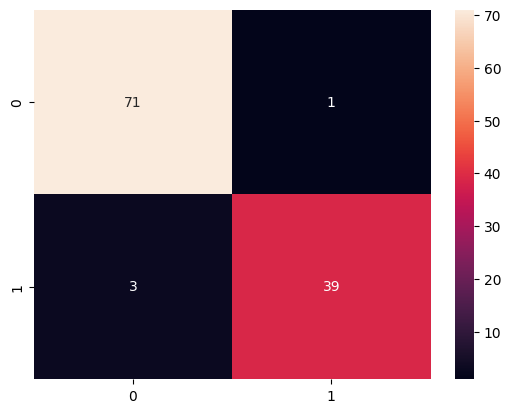

In [333]:
sns.heatmap(confusion_matrix(y_test, y_predict), annot=True)
plt.show()

Precision, recall, F1

In [334]:

precision = precision_score(y_test, y_predict)

recall = recall_score(y_test, y_predict)

f1 = f1_score(y_test, y_predict)

accuracy = accuracy_score(y_test, y_predict)

print(f"{precision=}\n{recall=}\n{f1=}\n{accuracy=}")

precision=0.975
recall=0.9285714285714286
f1=0.9512195121951219
accuracy=0.9649122807017544


In [335]:
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



Cross-validation yordamida tekshiramiz

In [336]:
# Cross validation
from sklearn.model_selection import cross_val_predict
predict = cross_val_predict(estimator = knn, X = X, y = y, cv = 5)

# Modelni baholash
print("Classification Report: \n",classification_report(y, predict))

Classification Report: 
               precision    recall  f1-score   support

           0       0.96      0.99      0.97       357
           1       0.98      0.93      0.95       212

    accuracy                           0.97       569
   macro avg       0.97      0.96      0.96       569
weighted avg       0.97      0.97      0.97       569



Eng yaxshi k ni topish

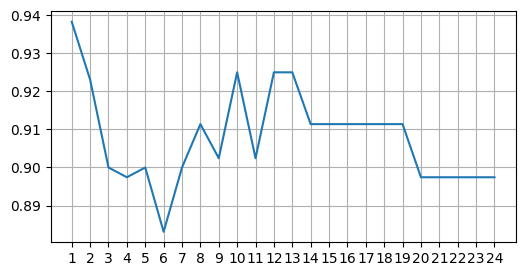

In [337]:
f1 = []
for k in range(1,25):
    knn = KNeighborsClassifier(n_neighbors=k) # k-ni qiymati
    knn.fit(X_train, y_train)
    y_predict = knn.predict(X_test)
    f1.append(f1_score(y_test, y_predict))

plt.figure(figsize=(6,3))
plt.plot(range(1,25),f1)
plt.xticks(range(1,25))
plt.grid()
plt.show()

Grid Search yordamida

In [338]:
from sklearn.model_selection import GridSearchCV

param_grid = {'n_neighbors': np.arange(1, 25)}

knn_gscv = GridSearchCV(knn, param_grid, cv=5)

knn_gscv.fit(X, y)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(n_neighbors=24),
             param_grid={'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24])})

In [339]:
print(knn_gscv.cv_results_['rank_test_score'])
print(knn_gscv.best_params_)
print(knn_gscv.best_score_)

[24 23 15 13  6  2  3  9  1  4  7 10  4 10  8 14 12 18 20 18 16 20 17 20]
{'n_neighbors': np.int64(9)}
0.968390001552554


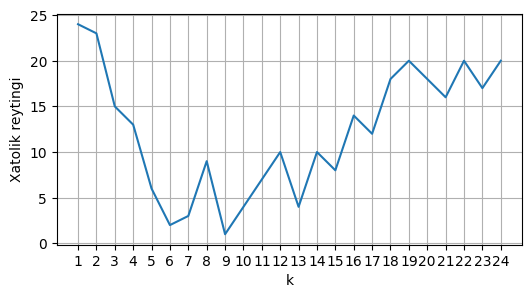

In [340]:
plt.figure(figsize=(6,3))
plt.plot(param_grid['n_neighbors'], knn_gscv.cv_results_['rank_test_score'])
plt.xticks(param_grid['n_neighbors'])
plt.xlabel("k")
plt.ylabel("Xatolik reytingi")
plt.grid()
plt.show()

### **Decision Tree**

1. Datasetdagi biror ustunni tanlaymiz
2. Malumotlarni bo'lishda ustun muhimligini aniqlaymiz
3. Eng yaxshi ustun bo'yicha malumotlarni bo'lamiz
4. Qadamlarni takrorlash

sklearn.tree.DecisionTreeClassifier(*, criterion='gini', splitter='best', max_depth=None, min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features=None, random_state=None, max_leaf_nodes=None, min_impurity_decrease=0.0, class_weight=None, ccp_alpha=0.0, monotonic_cst=None)

min_impurity_decrease' - natija qanchalik "toza" bo'lishini belgilaydi. Standart qiymati 0

max_depth - shajara qavatlari soni

min_samples_leaf - leaf node (yakuniy, barg tugun) hosil qilish uchun eng kam elementlar soni

In [341]:
#Entropia ni hisoblash formulasi . Entropia qancha kichik bo'lsa shuncha yaxshi
Image(url='https://www.researchgate.net/publication/372233393/figure/fig9/AS:11431281173487072@1688949412713/Figura-1-Formula-de-la-entropia-de-la-Teoria-Matematica-de-la-Informacion-de-Shannon.png')

In [342]:

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/drug200.csv"
df = pd.read_csv(url)

In [343]:
# Matnli ustunlarga ishlov
encoder = LabelEncoder()
df['Sex'] = encoder.fit_transform(df['Sex'].values)
df['BP'] = encoder.fit_transform(df['BP'].values)
df['Cholesterol'] = encoder.fit_transform(df['Cholesterol'].values)

X = df[['Age','Sex','BP','Cholesterol','Na_to_K']].values

y = df['Drug'].values

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=20)

# Model

tree_model = DecisionTreeClassifier()
tree_model.fit(X_train, y_train)

# Baholash

y_predict = tree_model.predict(X_test)

print(classification_report(y_test, y_predict))

print("DecisionTrees's Accuracy: ", accuracy_score(y_test, y_predict))

              precision    recall  f1-score   support

       drugA       1.00      1.00      1.00         7
       drugB       1.00      1.00      1.00         4
       drugC       0.75      1.00      0.86         9
       drugX       1.00      0.81      0.89        21
       drugY       0.97      1.00      0.99        39

    accuracy                           0.95        80
   macro avg       0.94      0.96      0.95        80
weighted avg       0.96      0.95      0.95        80

DecisionTrees's Accuracy:  0.95


In [344]:
feature_names = list(df[['Age','Sex','BP','Cholesterol','Na_to_K']].columns)
print(export_text(tree_model,feature_names=feature_names))

|--- Na_to_K <= 14.63
|   |--- BP <= 0.50
|   |   |--- Age <= 50.50
|   |   |   |--- class: drugA
|   |   |--- Age >  50.50
|   |   |   |--- class: drugB
|   |--- BP >  0.50
|   |   |--- Na_to_K <= 7.32
|   |   |   |--- class: drugC
|   |   |--- Na_to_K >  7.32
|   |   |   |--- BP <= 1.50
|   |   |   |   |--- Cholesterol <= 0.50
|   |   |   |   |   |--- class: drugC
|   |   |   |   |--- Cholesterol >  0.50
|   |   |   |   |   |--- class: drugX
|   |   |   |--- BP >  1.50
|   |   |   |   |--- class: drugX
|--- Na_to_K >  14.63
|   |--- class: drugY



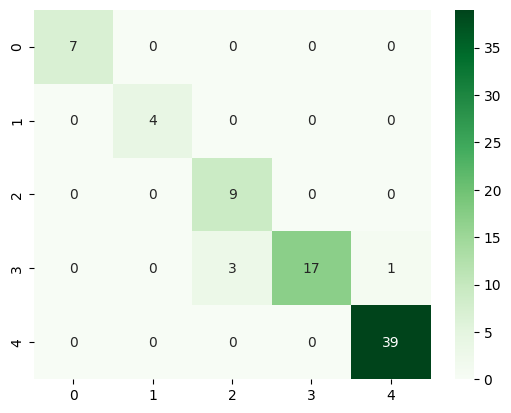

In [345]:
sns.heatmap(confusion_matrix(y_test, y_predict), annot=True, cmap="Greens")
plt.show()

In [346]:
# Cross Validation

predict = cross_val_predict(estimator = tree_model, X = X, y = y, cv = 5)
print("Classification Report: \n",classification_report(y, predict))

Classification Report: 
               precision    recall  f1-score   support

       drugA       0.92      1.00      0.96        23
       drugB       1.00      0.88      0.93        16
       drugC       1.00      1.00      1.00        16
       drugX       1.00      0.98      0.99        54
       drugY       0.99      1.00      0.99        91

    accuracy                           0.98       200
   macro avg       0.98      0.97      0.98       200
weighted avg       0.99      0.98      0.98       200



Decision Tree chizamiz

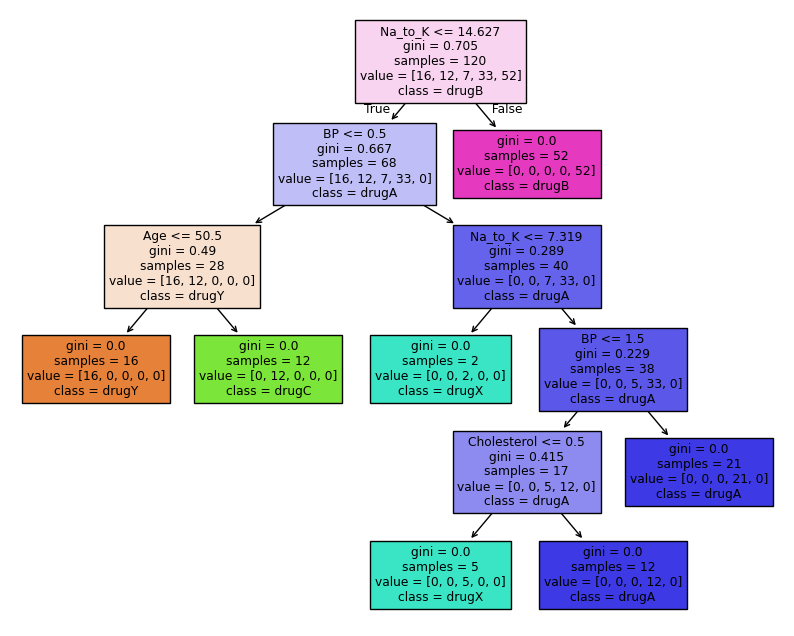

In [347]:
cols = df.drop('Drug', axis=1).columns
classes = df['Drug'].unique()

plt.figure(figsize=(10,8))
plot_tree(tree_model, feature_names=cols, class_names=classes,filled=True)
plt.show()

### **Hyperparameters**

Har bir model o'ziga xos **giperparametrlar** bilan keladi, biz bu parametrlarni sozlash orqali model aniqligini yoki tezligini oshirishimiz mumkin.

k-NN uchun bu k ya'ni qo'shnilar soni edi. Decision Treen da esa bir nechta giperparametrlar mavjud.

Barcha parametrlarni ushbu link orqali ko'rishingiz mumkin: https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

**`min_impurity_decrease'** - natija qanchalik "toza" bo'lishini belgilaydi. **Standart qiymati 0**

DecisionTrees's Accuracy:  0.875


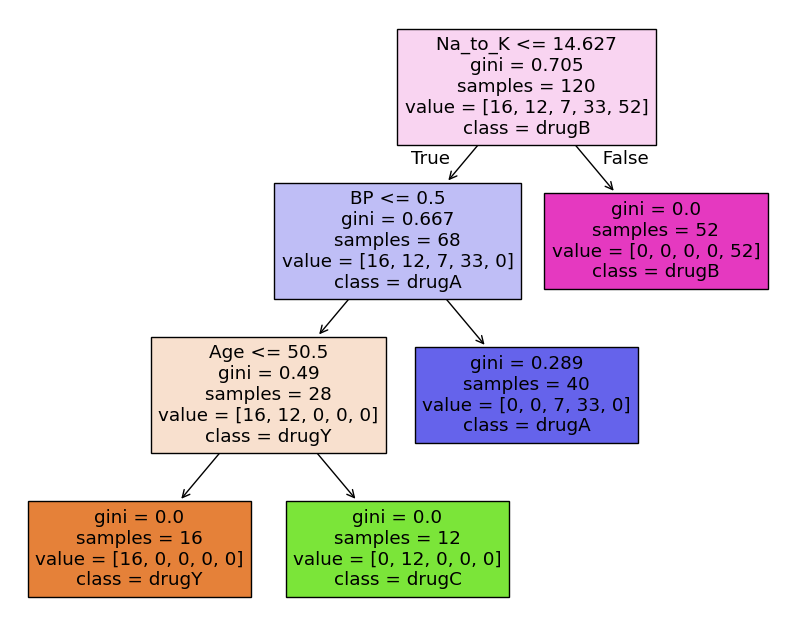

In [348]:
# min_samples_leaf - leaf node (yakuniy, barg tugun) hosil qilish uchun eng kam elementlar soni
# max_depth - shajara qavatlari soni

tree_model = DecisionTreeClassifier(min_impurity_decrease=0.1, max_depth=3, min_samples_leaf=5)
tree_model.fit(X_train, y_train)
y_predict = tree_model.predict(X_test)
print("DecisionTrees's Accuracy: ", accuracy_score(y_test, y_predict))

plt.figure(figsize=(10,8))
plot_tree(tree_model, feature_names=cols, class_names=classes,filled=True)
plt.show()

### **Random Forest**

sklearn.ensemble.RandomForestClassifier(n_estimators=100, *, criterion='gini', max_depth=None, min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features='sqrt', max_leaf_nodes=None, min_impurity_decrease=0.0, bootstrap=True, oob_score=False, n_jobs=None, random_state=None, verbose=0, warm_start=False, class_weight=None, ccp_alpha=0.0, max_samples=None, monotonic_cst=None)

Random Forest — ko‘plab Decision Tree'larni birlashtirib, kuchliroq model hosil qiladigan ensemble machine learning algoritmi.

Ko‘pchilik daraxt qaysi classni tanlasa, Random Forest shu classni tanlaydi.

Har bir daraxt aynan bir xil bo‘lmasligi uchun Random Forest tasodifiylikdan foydalanadi.

Random rows
Datasetdan bootstrap sampling orqali turli samplelar olinadi.

Random features
Har bir splitda barcha featurelardan foydalanish shart emas.

Asosiy parametrlar:

n_estimators: Qaror derevalar soni (integer, default=100). Ushbu parametr, qancha ko'plab qaror derevalarini (decision trees) ishlatish kerakligini belgilaydi.

criterion: Qaror derevasi (decision tree) qurilishi (string, default='gini'). Ushbu parametr, qaror derevasi uchun qurilishi ni belgilaydi:

'gini': Gini impurity ni o'rnating.\
'entropy': Entropiya ni o'rnating.

max_depth: Qaror derevalarining maksimal qat'iyati (integer or None, default=None). Ushbu parametr, qaror derevalarining maksimal qat'iyatini chegaralaydi.

min_samples_split: Qaror derevasi uchun eng kichik namunalarning bo'linishi kerak bo'lgan minimal namunalar soni (integer or float, default=2). Ushbu parametr, qaror derevasi uchun namunalar sonini belgilaydi.

min_samples_leaf: Har bir qaror derevasi uchun eng kam namunalarni quyidagi qurilishni aniqlash (integer or float, default=1). Ushbu parametr, qaror derevalarining har bir qat'iyatida eng kam namunalar sonini belgilaydi.

max_features: Har bir qaror derevasi uchun qo'llanilishi mumkin bo'lgan maksimal xususiyatlar soni (int, float, string or None, default='sqrt'). Ushbu parametr, qaror derevasi uchun qo'llanilishi mumkin bo'lgan maksimal xususiyatlar sonini belgilaydi.

**n_estimators** - o'rmondagi daraxtlar soni.

In [349]:
rf_model = RandomForestClassifier(n_estimators=20)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
print(classification_report(y_test, y_pred))

print("DecisionTrees's Accuracy: ", accuracy_score(y_test, y_pred))



              precision    recall  f1-score   support

       drugA       1.00      1.00      1.00         7
       drugB       1.00      1.00      1.00         4
       drugC       1.00      0.89      0.94         9
       drugX       0.95      0.95      0.95        21
       drugY       0.97      1.00      0.99        39

    accuracy                           0.97        80
   macro avg       0.99      0.97      0.98        80
weighted avg       0.98      0.97      0.97        80

DecisionTrees's Accuracy:  0.975


In [350]:
# qaysi ustunlar muhimligini ko'rsatadi.

imp = pd.Series(rf_model.feature_importances_,
                index=feature_names).sort_values(ascending=False)
print(imp.head(3).round(4))

Na_to_K    0.5408
BP         0.2412
Age        0.1526
dtype: float64


In [351]:
from sklearn.model_selection import GridSearchCV

params = {"max_depth": [3, 5, 10, None],
          "max_features": ["sqrt", 0.5, None],
          "n_estimators": [1, 10, 100]}

from time import time
start = time()
gs = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1),
                  params, scoring="accuracy")

gs.fit(X_train, y_train)
end = time()

print(round(end - start, 4))
print(gs.best_params_)
print(round(gs.best_score_, 4))
print(round(gs.best_estimator_.score(X_test, y_test), 4))

26.8583
{'max_depth': 5, 'max_features': None, 'n_estimators': 100}
0.9833
0.9875


Logistic Regression -> Classification model -> asosan Binary Classification uchun ishlatladi.

# **Unsupervised Learning**

**Unsupervised Learning** (Nazoratsiz)

Ishlatilishi:

**Klasterlash** (guruhlash)

• Tavsiya tizimlari

• Yo'naltirilgan marketing

• Mijozlarni guruhlash

**Ma'lumot o'chamini kamaytirish (5D→2D)**

• Katta ma'lumotlarni vizualizasiya qilish

• Paramterlarni jamlash

• Ma'lumotlarni siqish

**Qonuniyatlarni topish**

**Anomal (noodatiy) qiymatlarni aniqlash**

In [352]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs


n_samples - nuqtalar soni

centers - klasterlar markazi (sentroid) koordinatalari

-cluster_std - markazdan standart og'ish

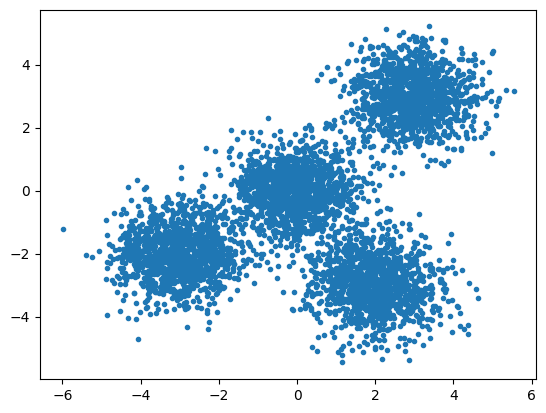

In [353]:
np.random.seed(0)
centroids = [[3,3], [-3, -2], [2, -3], [0, 0]]
X, y = make_blobs(n_samples=5000, centers=centroids, cluster_std=0.8)

plt.scatter(X[:, 0], X[:, 1], marker='.')
plt.show()

### **k-means algoritmi**

KMeans funksiyasi quyidagi parametrlarni qabul qiladi:

init - sentrodilarni tanlash usuli (k-means++ yoki random)

n_clusters - klastertlar soni

n_init - algoritmni necha marta ishga tushirish (turli sentroidlar bilan qayta-qayta ishga tushirib, modelni qurishni boshlash uchun eng yaxshi sentroidlar tanlanadi)

k-means algoritmi

- Har bir klaster uchun tasodifiy sentroidlarni tanlash
◦
- Har bir nuqtadan sentroidgacha masofani o'Ichash
◦
- Har bir nuqtani eng yaqin sentroidga biriktirish
◦
- Sentroidlarni siljitish
◦
- 2-4 qadamlarni setroidlar siljishi to'tagunga qadar takrorlash

In [354]:
k_means = KMeans(init = 'k-means++', n_clusters = 3, n_init = 15)

k_means.fit(X)

KMeans(n_clusters=3, n_init=15)

In [355]:
Image(url='https://miro.medium.com/v2/resize:fit:850/1*9ihLnBj-RV2h4e-VEimEbw.png', height=300)

#Elbow method -> Klasterlar soni k ni qanday tanlaymiz?

In [356]:
k_means.labels_   #Klaster raqamini ko'rish

k_means.cluster_centers_  # Klaster markazlarini ko'rish

print(centroids)

print(np.round(k_means.cluster_centers_))

[[3, 3], [-3, -2], [2, -3], [0, 0]]
[[-2. -1.]
 [ 3.  3.]
 [ 2. -3.]]


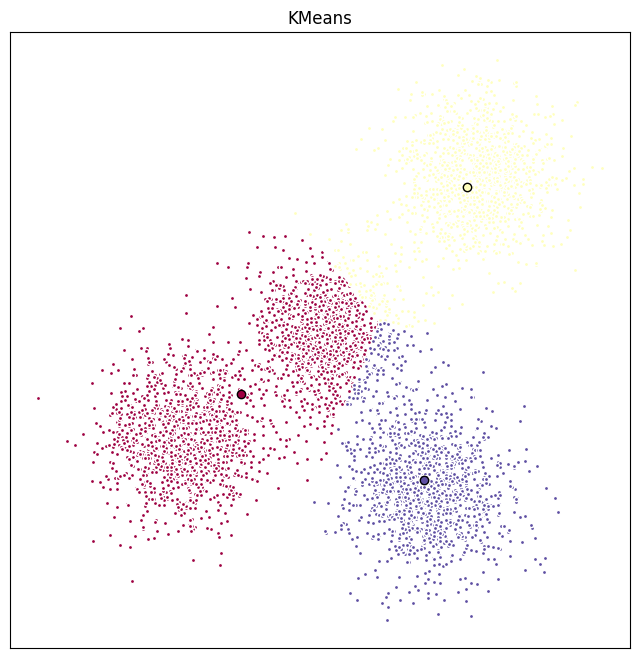

In [357]:
fig = plt.figure(figsize=(8, 8))
# Har bir klaster uchun alohida rang
colors = plt.cm.Spectral(np.linspace(0, 1, len(set(k_means.labels_))))
ax = fig.add_subplot(1, 1, 1)

for k, col in zip(range(len([[3,3], [-3, -2], [2, -3], [0, 0]])), colors):

    # Create a list of all data points, where the data points that are
    # in the cluster (ex. cluster 0) are labeled as true, else they are
    # labeled as false.
    my_members = (k_means.labels_ == k)

    # Define the centroid, or cluster center.
    cluster_center = k_means.cluster_centers_[k]

    # Plots the datapoints with color col.
    ax.plot(X[my_members, 0], X[my_members, 1], 'w', markerfacecolor=col, marker='.')

    # Plots the centroids with specified color, but with a darker outline
    ax.plot(cluster_center[0], cluster_center[1], 'o', markerfacecolor=col,  markeredgecolor='k', markersize=6)

# Title of the plot
ax.set_title('KMeans')

# Remove x-axis ticks
ax.set_xticks(())

# Remove y-axis ticks
ax.set_yticks(())

# Show the plot
plt.show()

In [358]:
url="https://raw.githubusercontent.com/anvarnarz/praktikum_datasets/main/customer_segmentation.csv"
df = pd.read_csv(url)
df.head()

,Customer Id,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,Address,DebtIncomeRatio
0,1,41,2,6,19,0.124,1.073,0.0,NBA001,6.3
1,2,47,1,26,100,4.582,8.218,0.0,NBA021,12.8
2,3,33,2,10,57,6.111,5.802,1.0,NBA013,20.9
3,4,29,2,4,19,0.681,0.516,0.0,NBA009,6.3
4,5,47,1,31,253,9.308,8.908,0.0,NBA008,7.2


In [359]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Customer Id      850 non-null    int64  
 1   Age              850 non-null    int64  
 2   Edu              850 non-null    int64  
 3   Years Employed   850 non-null    int64  
 4   Income           850 non-null    int64  
 5   Card Debt        850 non-null    float64
 6   Other Debt       850 non-null    float64
 7   Defaulted        700 non-null    float64
 8   Address          850 non-null    object 
 9   DebtIncomeRatio  850 non-null    float64
dtypes: float64(4), int64(5), object(1)
memory usage: 66.5+ KB


In [360]:
df.drop('Address', axis=1, inplace=True)
df.head()

,Customer Id,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio
0,1,41,2,6,19,0.124,1.073,0.0,6.3
1,2,47,1,26,100,4.582,8.218,0.0,12.8
2,3,33,2,10,57,6.111,5.802,1.0,20.9
3,4,29,2,4,19,0.681,0.516,0.0,6.3
4,5,47,1,31,253,9.308,8.908,0.0,7.2


In [361]:
from sklearn.preprocessing import StandardScaler
X = df.values[:,1:]
X = np.nan_to_num(X)
norm_data = StandardScaler().fit_transform(X)
norm_data

array([[ 0.74291541,  0.31212243, -0.37878978, ..., -0.59048916,
        -0.52379654, -0.57652509],
       [ 1.48949049, -0.76634938,  2.5737211 , ...,  1.51296181,
        -0.52379654,  0.39138677],
       [-0.25251804,  0.31212243,  0.2117124 , ...,  0.80170393,
         1.90913822,  1.59755385],
       ...,
       [-1.24795149,  2.46906604, -1.26454304, ...,  0.03863257,
         1.90913822,  3.45892281],
       [-0.37694723, -0.76634938,  0.50696349, ..., -0.70147601,
        -0.52379654, -1.08281745],
       [ 2.1116364 , -0.76634938,  1.09746566, ...,  0.16463355,
        -0.52379654, -0.2340332 ]])

In [362]:
k = 3
k_means = KMeans(n_clusters = k) # init va n_init standart qiymatlarni qabul qiladi, biz faqat klasterlar sonini ko'rsatdik.
k_means.fit(norm_data)
print(k_means.labels_)

[0 2 1 0 2 2 0 0 0 2 1 0 0 0 1 0 0 0 2 0 0 0 1 2 2 0 0 0 0 0 0 2 1 0 0 0 1
 1 0 2 1 2 0 2 0 2 0 0 0 0 2 2 1 0 1 1 1 0 0 0 2 0 2 2 0 0 0 1 0 1 0 0 0 0
 0 0 0 0 2 0 0 1 2 0 2 0 0 0 1 1 0 0 1 1 0 0 0 0 1 0 1 2 0 1 1 2 0 0 0 0 0
 0 0 1 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 2 0 0 1
 0 0 0 2 1 0 0 0 0 2 1 1 0 2 0 0 0 0 0 0 0 0 2 0 0 1 0 1 0 0 1 2 1 0 0 2 1
 2 0 0 0 0 0 2 0 1 0 0 0 2 2 0 2 0 1 0 0 1 0 2 0 1 0 0 0 0 0 1 1 2 0 0 1 2
 0 0 0 0 2 0 0 1 0 0 0 0 2 0 0 1 2 0 0 0 0 0 0 2 0 2 0 0 0 0 0 0 2 1 0 1 0
 0 0 2 0 1 2 1 0 2 0 0 1 0 0 0 0 1 1 1 0 0 0 2 0 0 2 0 2 0 0 2 0 0 0 1 0 0
 1 0 1 2 0 0 0 0 1 0 0 1 1 0 0 0 0 0 0 0 0 1 0 1 2 0 1 0 0 0 1 1 0 0 0 2 1
 0 0 1 0 2 0 0 0 0 0 1 2 0 0 0 0 0 2 0 0 0 0 0 2 0 0 0 2 1 0 1 0 0 0 2 2 0
 1 0 2 1 1 0 0 0 1 0 0 0 0 0 2 0 2 0 0 0 0 1 0 1 0 0 0 2 0 0 0 0 1 0 0 1 1
 2 0 0 0 0 0 1 1 0 2 1 2 0 0 1 0 0 2 2 0 1 0 0 2 0 1 0 2 0 0 0 2 0 0 0 0 2
 0 1 0 0 0 0 2 1 0 0 2 0 1 0 0 2 0 2 0 0 0 0 0 0 0 2 2 0 0 2 0 1 0 0 0 1 0
 1 0 0 0 0 0 2 1 1 0 2 0 

In [363]:
df['cluster'] = k_means.labels_
df.head()

,Customer Id,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio,cluster
0,1,41,2,6,19,0.124,1.073,0.0,6.3,0
1,2,47,1,26,100,4.582,8.218,0.0,12.8,2
2,3,33,2,10,57,6.111,5.802,1.0,20.9,1
3,4,29,2,4,19,0.681,0.516,0.0,6.3,0
4,5,47,1,31,253,9.308,8.908,0.0,7.2,2


In [364]:
df.groupby('cluster').mean()

,Customer Id,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio
cluster,,,,,,,,,
0,426.122905,33.817505,1.603352,7.625698,36.143389,0.853128,1.816855,0.000000,7.964991
1,424.451807,31.891566,1.861446,3.963855,31.789157,1.576675,2.843355,0.993939,13.994578
2,424.408163,43.000000,1.931973,17.197279,101.959184,4.220673,7.954483,0.162393,13.915646


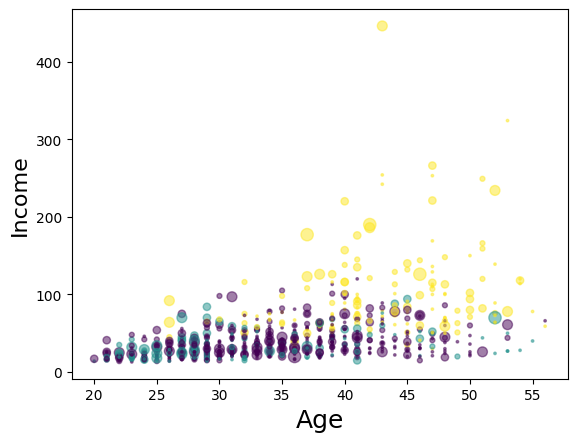

In [365]:
area = np.pi * ( X[:, 1])**2
plt.scatter(X[:, 0], X[:, 3], s=area, c=k_means.labels_.astype(float), alpha=0.5)
plt.xlabel('Age', fontsize=18)
plt.ylabel('Income', fontsize=16)

plt.show()

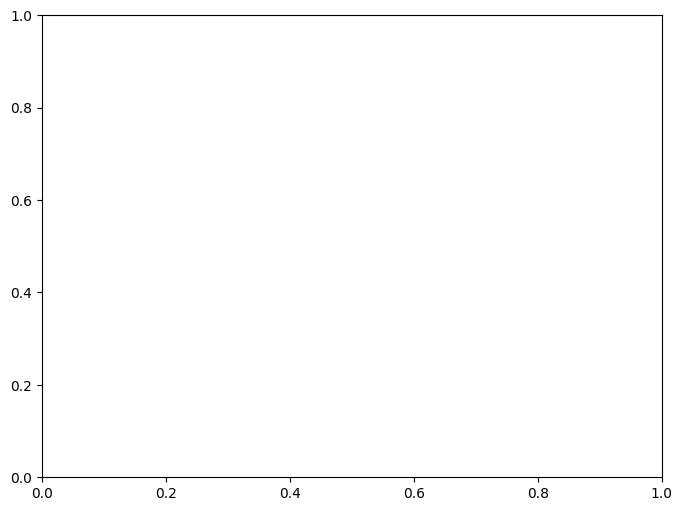

In [366]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(1, figsize=(8, 6))
plt.clf()
ax = Axes3D(fig, rect=[0, 0, .95, 1], elev=48, azim=120)

plt.cla()
# plt.ylabel('Age', fontsize=18)
# plt.xlabel('Income', fontsize=16)
# plt.zlabel('Education', fontsize=16)
ax.set_xlabel('Years Employed')
ax.set_ylabel('Age')
ax.set_zlabel('Income')

ax.scatter(X[:, 2], X[:, 0], X[:, 3], c= k_means.labels_.astype(float))

Afzalligi

Klasterlar sonini belgilash talab qilinmaydi

Oson

Dendogram yordamida ma'lumotni tahlil gilish oson

Kamchiliklari:

Avalgi qadamni bekor qilib bo'lmaydi

Uzoq vaqt oladi

Dendogramdan kerakli klasterlar sonini ajratib olish murakkab

Ierarxik (hierarchical) algoritm

- lerarxik klasterlash algoritmi klasterlar ierarxiyasini quradi, bunda har bir tugun klaster bo'ladi va o'zidan keying tugun klasterlarini o'z ichiga oladi.

In [367]:
Image(url='https://miro.medium.com/v2/resize:fit:1400/0*afzanWwrDq9vd2g-',height=300)

**Iyerarxik klasterlash qadamlari**

1. Har bir nugtani alohida klaster deb ajratib olamiz

2. Yaqinlik matrisasini quramiz

3. Bir dona klaster qolgunga qadar quidagi gadamlarni takrorlaymiz

     - Eng yagin ikki klasterni birlashtirish

     - Yaginlik matrisasini yangilash

**Klasterlar o'rtasidagi masofa**

- Single-linkage Clustering ->Klasterlar o'rtasidagi minimum masofa

- Complete-linkage Clustering -> Klasterlar o'rtasidagi maksimum masofa

- Average Linkage clustering -> Klasterlar o'rtasidagi o'rta masofa

- Centroid Linkage clustering -> Klaster markazlari orasidagi masofa

In [368]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%204/data/cars_clus.csv"
df = pd.read_csv(url)
df.head()

,manufact,model,sales,resale,type,price,engine_s,horsepow,wheelbas,width,length,curb_wgt,fuel_cap,mpg,lnsales,partition
0,Acura,Integra,16.919,16.360,0.000,21.500,1.800,140.000,101.200,67.300,172.400,2.639,13.200,28.000,2.828,0.0
1,Acura,TL,39.384,19.875,0.000,28.400,3.200,225.000,108.100,70.300,192.900,3.517,17.200,25.000,3.673,0.0
2,Acura,CL,14.114,18.225,0.000,$null$,3.200,225.000,106.900,70.600,192.000,3.470,17.200,26.000,2.647,0.0
3,Acura,RL,8.588,29.725,0.000,42.000,3.500,210.000,114.600,71.400,196.600,3.850,18.000,22.000,2.150,0.0
4,Audi,A4,20.397,22.255,0.000,23.990,1.800,150.000,102.600,68.200,178.000,2.998,16.400,27.000,3.015,0.0


In [369]:
df[[ 'sales', 'resale', 'type', 'price', 'engine_s',
       'horsepow', 'wheelbas', 'width', 'length', 'curb_wgt', 'fuel_cap',
       'mpg', 'lnsales']] = df[['sales', 'resale', 'type', 'price', 'engine_s',
       'horsepow', 'wheelbas', 'width', 'length', 'curb_wgt', 'fuel_cap',
       'mpg', 'lnsales']].apply(pd.to_numeric, errors='coerce') # raqamli ustunga aylantirish
df = df.dropna()
df = df.reset_index(drop=True) # indexni tashlab yuborish
df.head(5)

,manufact,model,sales,resale,type,price,engine_s,horsepow,wheelbas,width,length,curb_wgt,fuel_cap,mpg,lnsales,partition
0,Acura,Integra,16.919,16.360,0.0,21.50,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,2.828,0.0
1,Acura,TL,39.384,19.875,0.0,28.40,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0,3.673,0.0
2,Acura,RL,8.588,29.725,0.0,42.00,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0,2.150,0.0
3,Audi,A4,20.397,22.255,0.0,23.99,1.8,150.0,102.6,68.2,178.0,2.998,16.4,27.0,3.015,0.0
4,Audi,A6,18.780,23.555,0.0,33.95,2.8,200.0,108.7,76.1,192.0,3.561,18.5,22.0,2.933,0.0


In [370]:
# Klasterlash uchun ustunlarni tanlab olamiz.
featureset = df[['engine_s',  'horsepow', 'wheelbas', 'width', 'length', 'curb_wgt', 'fuel_cap', 'mpg']]

# Normalizasiya

x = featureset.values #numpy array
min_max_scaler = MinMaxScaler()
feature_mtx = min_max_scaler.fit_transform(x)
feature_mtx[0:5]

array([[0.11428571, 0.21518987, 0.18655098, 0.28143713, 0.30625832,
        0.2310559 , 0.13364055, 0.43333333],
       [0.31428571, 0.43037975, 0.3362256 , 0.46107784, 0.5792277 ,
        0.50372671, 0.31797235, 0.33333333],
       [0.35714286, 0.39240506, 0.47722343, 0.52694611, 0.62849534,
        0.60714286, 0.35483871, 0.23333333],
       [0.11428571, 0.24050633, 0.21691974, 0.33532934, 0.38082557,
        0.34254658, 0.28110599, 0.4       ],
       [0.25714286, 0.36708861, 0.34924078, 0.80838323, 0.56724368,
        0.5173913 , 0.37788018, 0.23333333]])

Irarxik klasterlash uchun Scipy paketidan foydalanmiz.

Boshlanishiga distance matrix D (masofalar matrisasini) quramiz:

In [371]:
import scipy
from scipy import ndimage
from scipy.cluster import hierarchy
from scipy.spatial import distance_matrix

leng = feature_mtx.shape[0]
D = np.zeros([leng,leng])
for i in range(leng):
    for j in range(leng):
        D[i,j] = scipy.spatial.distance.euclidean(feature_mtx[i], feature_mtx[j])
D

array([[0.        , 0.57777143, 0.75455727, ..., 0.28530295, 0.24917241,
        0.18879995],
       [0.57777143, 0.        , 0.22798938, ..., 0.36087756, 0.66346677,
        0.62201282],
       [0.75455727, 0.22798938, 0.        , ..., 0.51727787, 0.81786095,
        0.77930119],
       ...,
       [0.28530295, 0.36087756, 0.51727787, ..., 0.        , 0.41797928,
        0.35720492],
       [0.24917241, 0.66346677, 0.81786095, ..., 0.41797928, 0.        ,
        0.15212198],
       [0.18879995, 0.62201282, 0.77930119, ..., 0.35720492, 0.15212198,
        0.        ]])

In [372]:
# training
Z = hierarchy.linkage(D)

/tmp/ipykernel_1098/2369392655.py:2: ClusterWarning:

The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix



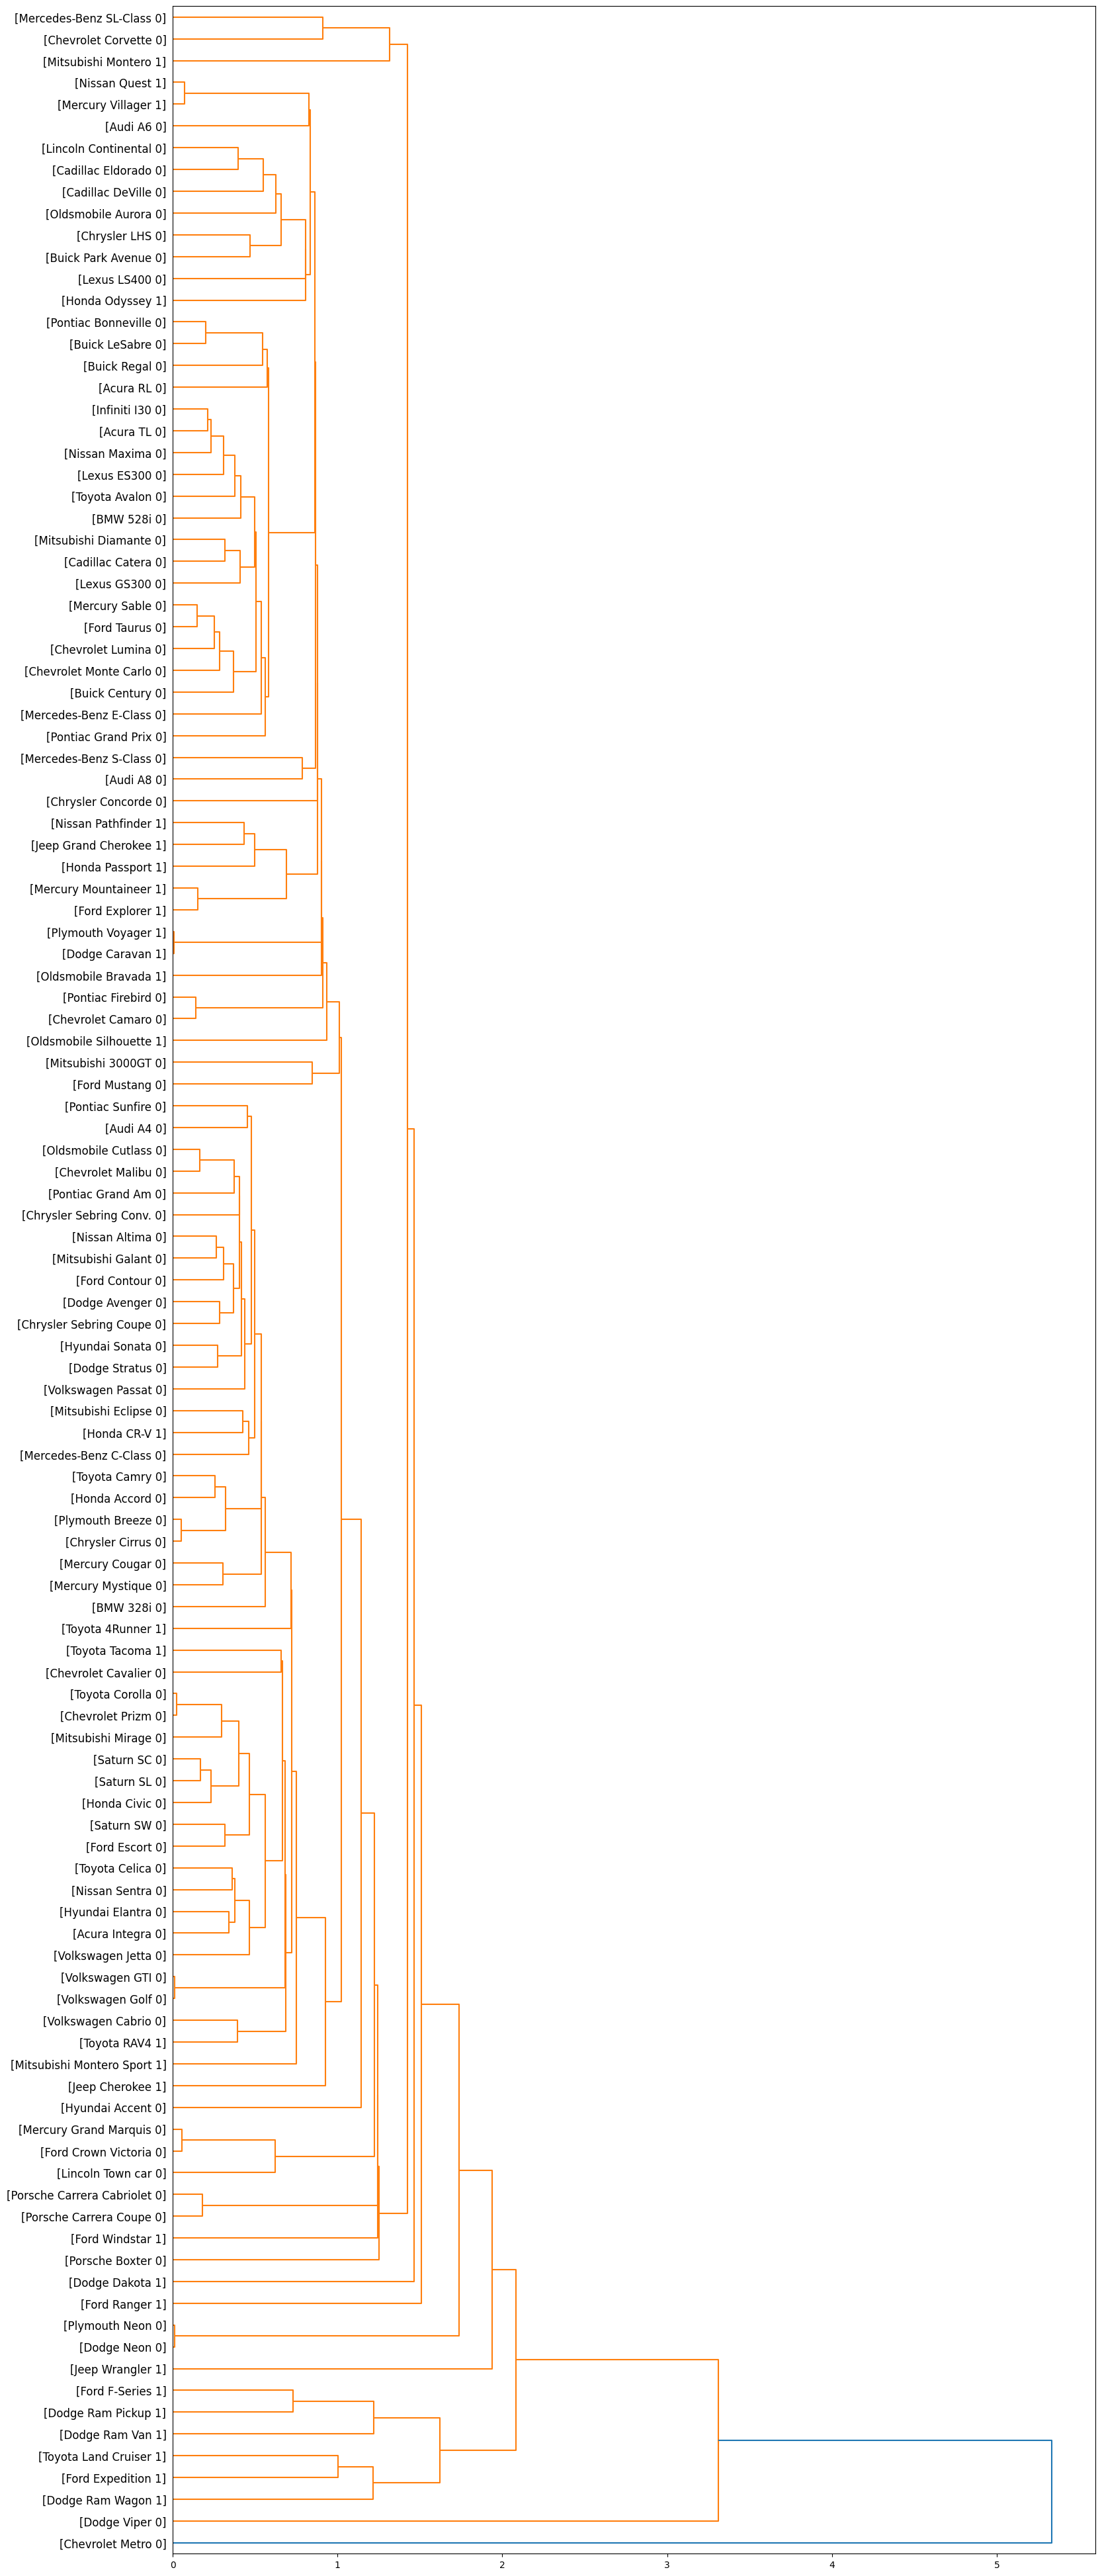

In [373]:
# Dendogram

fig = plt.figure(figsize=(18,50))
def llf(id):
    return '[%s %s %s]' % (df['manufact'][id], df['model'][id], int(float(df['type'][id])) )

dendro = hierarchy.dendrogram(Z,  leaf_label_func=llf, leaf_rotation=0, leaf_font_size =12, orientation = 'right')

In [374]:
from scipy.cluster.hierarchy import fcluster
k = 5 # 5 ta klaster
clusters = fcluster(Z, k, criterion='maxclust')
clusters

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       5, 2, 2, 2, 2, 2, 2, 2, 2, 4, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       1, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 1, 2, 2, 2, 2, 2], dtype=int32)

In [375]:
# scikit yordamida klasterlash

from sklearn import manifold, datasets
from sklearn.cluster import AgglomerativeClustering

agglom = AgglomerativeClustering(n_clusters = 6, linkage = 'complete')
agglom.fit(D)

agglom.labels_

/usr/local/lib/python3.13/dist-packages/sklearn/cluster/_agglomerative.py:588: ClusterWarning:

The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix



array([1, 2, 2, 3, 2, 4, 3, 2, 2, 2, 2, 2, 4, 4, 2, 1, 3, 2, 2, 2, 4, 1,
       5, 3, 3, 2, 3, 2, 1, 3, 3, 0, 0, 0, 0, 4, 2, 1, 3, 3, 2, 4, 2, 4,
       0, 3, 0, 1, 3, 3, 2, 4, 1, 1, 3, 2, 1, 3, 2, 2, 2, 4, 4, 4, 1, 3,
       3, 2, 3, 4, 3, 3, 3, 2, 4, 2, 2, 3, 2, 4, 4, 1, 3, 2, 2, 2, 3, 4,
       2, 4, 1, 3, 2, 3, 3, 2, 2, 2, 3, 3, 3, 1, 1, 1, 1, 3, 2, 1, 1, 1,
       3, 0, 1, 1, 3, 1, 1])

**k-means**

Tez, katta datasetlarda qo'llash mumkin

Klasterlar sonini oldindan ko'rsatish kerak

Faqatgina bitta variant beradi

Sentroidlarni tasodifiy tanlash evaziga har doim har xil
natija qaytadi

**lyerarxik algoritm**

Sekin, katta datasetlarda hisob-kitob uzoq vaqt oladi

Klasterlar soni talab qilinmaydi

Dendogramdan klasterlar sonini o'zgartirishimiz
mumkin

Har doim bir xil klasterlarni qaytaradi

 **DBSCAN** --> Densitiy-Based Spatial Clustering of Application with Noise

 • Eng ko'p qo'llaniladigan algoritm

• Asosiy g'oya: Biror nuqta klasterga tegishli bo'lsa bu
nuqta atrofida klasterga tegishli boshqa ko'plab nuqtalar
bo'lishi kerak

**• Asosiy parametrlari:**

• R (qo'shni nuqtalargacha radius) - berilgan radisudagi
qo'shnilar soni

• M (minimum qo'shnilar soni) - klaster shakllantirish
uchun minimum nuqtalar soni

**Avzalliklari:**

◦	Istalgan shakldagi klasterlarni aniqlaydi

◦	Shovginga sezgir va noodatiy qiymatlarni ajrata oladi

◦	Klasterlar sonini ko'rsatish talab qilinmaydi

k-means noodatiy giymatlarni ham klasterga biriktiradi

DBSCAN Zichlik asosidagi algoritmlar zich joylashgan hududlarni birlashtirib, noodatiy qiymatlarni ajratib beradi

In [376]:
Image(url='https://miro.medium.com/v2/resize:fit:1358/1*KqWII7sFp1JL0EXwJGpqFw.png',height=300)

Nuqtalar 3 turli bo'lishi mumkin:
- Core (markaz)
- Border (chegara)
- Outlier (noodatiy)

DBSCAN maqsadi:

• har bir nuqtani tahlil qilish va yuqoridagi turlardan biriga
ajratish

• Nuqtalarni klasterlarga ajratish

**Klaster:** Barcha go'shni Markaz nuqtalar va ularga tegishli Chegara nuqtalar.

**Core point:**

  R radiusda kamida M nuqta bilan tutashgan nuqta.

**Border point:**

  M dan kam nuqtalar bilan tutash yoki Core point bilan qo'shni.

**Outlier point:**

  Markaz yoki Chegara bo’magan nuqta.

# **Scikit_learn**

### Imputers

sklearn.impute

class sklearn.impute.SimpleImputer(*, missing_values=nan, strategy='mean', fill_value=None, copy=True, add_indicator=False, keep_empty_features=False)

In [379]:
from sklearn.impute import SimpleImputer, KNNImputer

# SimpleImputer klassidan yangi obyekt yaratamiz va NaN qiymatlarni median qiymat bilan to'ldirishni ko'rsatamiz
imputer = SimpleImputer(strategy="median")
imputer.fit(housing_num) # median qiymatlarni hisoblash
imputer.statistics_ # hisoblangan median qiymatlarni ko'rish

X = imputer.transform(housing_num) # NaN qiymatlarni median qiymat bilan to'ldirish
X = imputer.fit_transform(housing_num)

housing = pd.DataFrame(X, columns=housing_num.columns, index=housing_num.index) # np.array dan Df ga o'tkazish

class sklearn.impute.KNNImputer(*, missing_values=nan, n_neighbors=5, weights='uniform', metric='nan_euclidean', copy=True, add_indicator=False, keep_empty_features=False)

n_neighbors: Necha qo'shni (neighbors) ko'rib chiqilishini belgilaydi. Default qiymat 5.

weights: Qo'shnilarning qiymatlari qanday og'irlik bilan hisoblanishini belgilaydi. "uniform" qiymati barcha qo'shnilarni teng og'irlikda hisoblaydi, "distance" esa masofaga qarab og'irlik beradi.

In [380]:
# Misol ma'lumotlar to'plami
data = np.array([[1, 2, np.nan],
                 [3, np.nan, 5],
                 [np.nan, 4, 6]])

# Imputer yaratish
imputer = KNNImputer(n_neighbors=2)

# Yo'qolgan qiymatlarni to'ldirish
imputed_data = imputer.fit_transform(data)

print(imputed_data)

[[1.  2.  5.5]
 [3.  3.  5. ]
 [2.  4.  6. ]]


### Scalers

sklearn.preprocessing

StandardScaler outlierlar bo'lsa yaxshi

class sklearn.preprocessing.StandardScaler(*, copy=True, with_mean=True, with_std=True)

Standard Scaling formulasi:

$$
z = \frac{x - \mu}{\sigma}
$$

Bu yerda:

- $x$ — original qiymat
- $\mu$ — feature'ning o‘rtacha qiymati (`mean`)
- $\sigma$ — standart og‘ish (`standard deviation`)
- $z$ — scaling qilingan qiymat

Natijada feature odatda:

$$
\text{Mean} = 0
$$

$$
\text{Standard Deviation} = 1
$$

In [381]:
from sklearn.preprocessing import StandardScaler

data = np.array([[1, 2], [3, 4], [5, 6]])

# StandardScaler ob'ektini yaratish
scaler = StandardScaler()

# Ma'lumotlarni o'zgartirish
scaled_data = scaler.fit_transform(data)

print("Asl ma'lumotlar:")
print(data)

print("Standartlashtirilgan ma'lumotlar:")
print(scaled_data)

Asl ma'lumotlar:
[[1 2]
 [3 4]
 [5 6]]
Standartlashtirilgan ma'lumotlar:
[[-1.22474487 -1.22474487]
 [ 0.          0.        ]
 [ 1.22474487  1.22474487]]


MinMaxScaler outlierlar bo'lsa yamon

class sklearn.preprocessing.MinMaxScaler(feature_range=(0, 1), *, copy=True, clip=False)

Min-Max Scaling formulasi:

$$
x' = \frac{x - x_{min}}{x_{max} - x_{min}}
$$

Bu yerda:

- $x$ — original qiymat
- $x_{min}$ — feature'dagi minimal qiymat
- $x_{max}$ — feature'dagi maksimal qiymat
- $x'$ — scaling qilingan qiymat

Natijada qiymatlar odatda:

$$
0 \leq x' \leq 1
$$

In [382]:
from sklearn.preprocessing import MinMaxScaler

# Misol ma'lumotlar
data = np.array([[1, 2], [3, 4], [5, 6]])

# MinMaxScaler ob'ektini yaratish
scaler = MinMaxScaler(feature_range=(0, 1))

# Ma'lumotlarni shkalalash
scaled_data = scaler.fit_transform(data)

print("Asl ma'lumotlar:")
print(data)

print("Shkalalangan ma'lumotlar:")
print(scaled_data)

Asl ma'lumotlar:
[[1 2]
 [3 4]
 [5 6]]
Shkalalangan ma'lumotlar:
[[0.  0. ]
 [0.5 0.5]
 [1.  1. ]]


RobustScaler

class sklearn.preprocessing.RobustScaler(*, with_centering=True, with_scaling=True, quantile_range=(25.0, 75.0), copy=True, unit_variance=False)

RobustScaler - bu Scikit-learn kutubxonasidagi funksiya bo'lib, sonli ma'lumotlarni standartlashtirish uchun ishlatiladi, lekin u outlier (juda katta yoki juda kichik qiymatlar) larni inobatga olgan holda ishlaydi.

o'rtacha va std o'rniga median va iqr ishlatadi.

standart scaler = (x-mean)/std | rebustscalaer = (x-median)/iqr

outlierlar oddiy shkalalash usullariga (masalan, StandardScaler yoki MinMaxScaler) ta'sir qilishi mumkin.

In [383]:
from sklearn.preprocessing import RobustScaler

# Misol ma'lumotlar
data = np.array([[1, 2], [3, 4], [5, 100]])

# RobustScaler ob'ektini yaratish
scaler = RobustScaler()

# Ma'lumotlarni shkalalash
scaled_data = scaler.fit_transform(data)

print("Asl ma'lumotlar:")
print(data)

print("Shkalalangan ma'lumotlar:")
print(scaled_data)

Asl ma'lumotlar:
[[  1   2]
 [  3   4]
 [  5 100]]
Shkalalangan ma'lumotlar:
[[-1.         -0.04081633]
 [ 0.          0.        ]
 [ 1.          1.95918367]]


MaxAbsScaler

class sklearn.preprocessing.MaxAbsScaler(*, copy=True)

ma'lumotlarni -1 va 1 oralig'iga moslaydi.

In [384]:
from sklearn.preprocessing import MaxAbsScaler

# Misol ma'lumotlar
data = np.array([[1, 2], [3, 4], [5, 6]])

# MaxAbsScaler ob'ektini yaratish
scaler = MaxAbsScaler()

# Ma'lumotlarni shkalalash
scaled_data = scaler.fit_transform(data)

print("Asl ma'lumotlar:")
print(data)

print("Shkalalangan ma'lumotlar:")
print(scaled_data)

Asl ma'lumotlar:
[[1 2]
 [3 4]
 [5 6]]
Shkalalangan ma'lumotlar:
[[0.2        0.33333333]
 [0.6        0.66666667]
 [1.         1.        ]]


### Encoders

OrdinalEncoder - bu Scikit-learn kutubxonasidagi funksiya bo'lib, kategorik (nominal) ma'lumotlarni raqamli (numerical) kodlarga o'zgartirish uchun ishlatiladi. Bu raqamli kodlar kategoriyalarning tartibiga (ordinal) muvofiq bo'ladi.

class sklearn.preprocessing.OrdinalEncoder(*, categories='auto', dtype=<class 'numpy.float64'>, handle_unknown='error', unknown_value=None, encoded_missing_value=nan, min_frequency=None, max_categories=None)

In [385]:
from sklearn.preprocessing import OrdinalEncoder

# Misol ma'lumotlar
data = np.array([['qizil'], ['yashil'], ['ko\'k'], ['qizil']])

# OrdinalEncoder ob'ektini yaratish
encoder = OrdinalEncoder()

# Ma'lumotlarni kodlash
encoded_data = encoder.fit_transform(data)

print("Asl ma'lumotlar:")
print(data)

print("Kodlangan ma'lumotlar:")
print(encoded_data)

Asl ma'lumotlar:
[['qizil']
 ['yashil']
 ["ko'k"]
 ['qizil']]
Kodlangan ma'lumotlar:
[[1.]
 [2.]
 [0.]
 [1.]]


OneHotEncoder - bu Scikit-learn kutubxonasidagi funksiya bo'lib, kategorik (nominal) ma'lumotlarni bir-biriga bog'liq bo'lmagan ikkilik (binary) kodlarga o'zgartirish uchun ishlatiladi. Bu kodlash usuli "one-hot encoding" deb ataladi va har bir kategoriya uchun alohida ustun (feature) yaratadi, unda faqat bitta ustun qiymati 1 bo'ladi, qolganlari esa 0 bo'ladi.

class sklearn.preprocessing.OneHotEncoder(*, categories='auto', drop=None, sparse_output=True, dtype=<class 'numpy.float64'>, handle_unknown='error', min_frequency=None, max_categories=None, feature_name_combiner='concat')

Parametrlar
categories: Kategoriyalarni aniqlash usuli. Default qiymat 'auto' bo'lib, bu barcha kategoriyalarni avtomatik ravishda aniqlashni anglatadi.\

drop: Ba'zi kategoriyalarni tushirib qoldirish uchun ishlatiladi. Bu multikollinerlikni oldini olish uchun foydali bo'lishi mumkin.\

sparse_output: True bo'lsa, natija siyrak matritsa (sparse matrix) sifatida qaytariladi. False bo'lsa, natija oddiy numpy array sifatida qaytariladi. Default qiymat True.\

dtype: Kodlangan ma'lumotlarning turini aniqlaydi. Default qiymat numpy.float64.

In [386]:
from sklearn.preprocessing import OneHotEncoder

# Misol ma'lumotlar
data = np.array([['qizil'], ['yashil'], ['ko\'k'], ['qizil']])

# OneHotEncoder ob'ektini yaratish
encoder = OneHotEncoder(sparse_output=False)

# Ma'lumotlarni kodlash
encoded_data = encoder.fit_transform(data)

print("Asl ma'lumotlar:")
print(data)

print("Kodlangan ma'lumotlar:")
print(encoded_data)

Asl ma'lumotlar:
[['qizil']
 ['yashil']
 ["ko'k"]
 ['qizil']]
Kodlangan ma'lumotlar:
[[0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]]


class sklearn.preprocessing.LabelEncode

In [387]:
from sklearn.preprocessing import LabelEncoder

# Misol ma'lumotlar
data = ['qizil', 'yashil', 'ko\'k', 'qizil']

# LabelEncoder ob'ektini yaratish
encoder = LabelEncoder()

# Ma'lumotlarni kodlash
encoded_data = encoder.fit_transform(data)

print("Asl ma'lumotlar:")
print(data)

print("Kodlangan ma'lumotlar:")
print(encoded_data)

# Kodlangan ma'lumotlarni dekodlash
decoded_data = encoder.inverse_transform(encoded_data)
print("Dekodlangan ma'lumotlar:")
print(decoded_data)

Asl ma'lumotlar:
['qizil', 'yashil', "ko'k", 'qizil']
Kodlangan ma'lumotlar:
[1 2 0 1]
Dekodlangan ma'lumotlar:
['qizil' 'yashil' "ko'k" 'qizil']


sklearn.preprocessing.TargetEncoder(categories='auto', target_type='auto', smooth='auto', cv=5, shuffle=True, random_state=None)

Parametrlar

categories: Kategoriyalarni aniqlash usuli. Default qiymat 'auto' bo'lib, bu barcha kategoriyalarni avtomatik ravishda aniqlashni anglatadi.

target_type: Maqsad qiymatining turini belgilaydi (masalan, regressiya uchun 'continuous' yoki klassifikatsiya uchun 'binary').

smooth: Smuzlash darajasini belgilaydi. Bu parameter kodlarni smuzlash uchun ishlatiladi va overfittingni oldini oladi.

cv: Kross-validatsiya qatlamlari soni. Default qiymat 5.

shuffle: Ma'lumotlarni aralashtirish kerakligini belgilaydi. Default qiymat True.

random_state: Tasodifiy sonlar generatorining boshlang'ich qiymatini belgilaydi.

LabelEncoder: Kategoriyalar o'rtasida aniq tartib mavjud bo'lsa va u tartib mashinalarning tushunishida muhim bo'lsa.

TargetEncoder: Kategorik ma'lumotlar maqsadga qarab bog'liq bo'lsa va u maqsadning o'rtacha qiymatini hisobga olish muhim bo'lsa, masalan, regressiya modellarida.

OrdinalEncoder: Kategoriyalar o'rtasida aniq tartib mavjud bo'lsa va u tartib mashinalarning tushunishida muhim bo'lsa, masalan, ordinal klassifikatsiya modellarida.

OneHotEncoder: Kategorik ma'lumotlarni mashinalarning o'rganish algoritmlariga berishda ishlatiladi, chunki ba'zi algoritmlar to'g'ri ishlaydi binary ma'lumotlari bilan.

| Encoding turi      | Qachon ishlatiladi?                                                 | Misol               | Natija                     |
| ------------------ | ------------------------------------------------------------------- | ------------------- | -------------------------- |
| Label Encoding     | Asosan target `y` kategorik bo'lganda                               | `Cat, Dog, Bird`    | `0, 1, 2`                  |
| Ordinal Encoding   | Kategoriyalar orasida tabiiy tartib bo'lsa                          | `Low, Medium, High` | `0, 1, 2`                  |
| One-Hot Encoding   | Kategoriyalar orasida tartib bo'lmasa                               | `Red, Blue, Green`  | Alohida 0/1 ustunlar       |
| Binary Encoding    | Kategoriya juda ko'p bo'lsa                                         | `1000+ ta shahar`   | Binary ustunlar            |
| Target Encoding    | Kategoriya juda ko'p bo'lsa va target bilan bog'lash foydali bo'lsa | `City → Salary`     | Target statistikasi        |
| Frequency Encoding | Kategoriyalar ko'p va ularning uchrashish soni muhim bo'lsa         | `City → count`      | Chastota                   |
| Hash Encoding      | Juda katta miqdordagi kategoriyalar bo'lsa                          | `User_ID`           | Belgilangan sonli ustunlar |


### sklearn.base

In [388]:
from sklearn.base import TransformerMixin

class CustomScaler(TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        # Ma'lumotlarni o'rganish, masalan, o'rtacha va standart deviasi hisoblash
        self.mean_ = X.mean(axis=0)
        self.std_ = X.std(axis=0)
        return self

    def transform(self, X):
        # Ma'lumotlarni o'zgartirish, masalan, standartizatsiya
        X_transformed = (X - self.mean_) / self.std_
        return X_transformed

# CustomScaler dan obyekt yaratish
scaler = CustomScaler()

# fit() metodi orqali ma'lumotlarni o'rganish
# scaler.fit(X_train)

# transform() metodi orqali ma'lumotlarni transformatsiya qilish
# X_train_transformed = scaler.transform(X_train)

### **sklearn.pipeline**

In [389]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

num_pipeline = Pipeline([
          ('imputer', SimpleImputer(strategy='median')),
         # ('attribs_adder', CombinedAttributesAdder(add_bedrooms_per_room = True)),
          ('std_scaler', StandardScaler())
])

# num_attribs = list(X_num)
# cat_attribs = ['ocean_proximity']

full_pipeline = ColumnTransformer([
   # ('num', num_pipeline, num_attribs),
    #('cat', OneHotEncoder(), cat_attribs)
])

# X_prepared = full_pipeline.fit_transform(X_train)

sklearn.compose

class sklearn.compose.ColumnTransformer(transformers, *, remainder='drop', sparse_threshold=0.3, n_jobs=None, transformer_weights=None, verbose=False, verbose_feature_names_out=True, force_int_remainder_cols=True)

Parametrlar

transformers: Ajratiladigan xususiyatlar va ular uchun transformatsiya usullari ro'yxati.

remainder: Ajratilgan xususiyatlardan qolgan qismlarni qanday qilib boshqarish kerakligi. Agar 'drop' bo'lsa, qolgan qismlar o'chiriladi; 'passthrough' bo'lsa, boshqa transformatsiya usuliga o'tkazishsiz saqlanadi.

In [390]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
import numpy as np

# Misol ma'lumotlar
X = np.array([
    ['London', 25],
    ['Paris', 30],
    ['Madrid', 35],
    ['Berlin', 40],
    ['Rome', 45]
])

# ColumnTransformer ob'ektini yaratish
# Birinchi ustun uchun OneHotEncoder, ikkinchi ustun uchun StandardScaler qo'llash
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(), [0]),  # kategoriyal ma'lumotlar uchun
        ('num', StandardScaler(), [1])  # sonli ma'lumotlar uchun
    ],
    remainder='drop',  # qolgan qismlar o'chiriladi
    sparse_threshold=0.3  # qoraliqli matn bo'lsa, qoraliq miqdorini aniqlaydi
)

# Ma'lumotlarni transform qilish
transformed_data = preprocessor.fit_transform(X)

print("Transformatsiyalangan ma'lumotlar:")
print(transformed_data) # sparse matrix ni to'g'ri ko'rsatish uchun toarray() metodi

# Natijada kategoriyal ma'lumotlar OneHotEncoder bilan kodlangan, sonli ma'lumotlar esa standart skalerlashgan bo'ladi

Transformatsiyalangan ma'lumotlar:
[[ 0.          1.          0.          0.          0.         -1.41421356]
 [ 0.          0.          0.          1.          0.         -0.70710678]
 [ 0.          0.          1.          0.          0.          0.        ]
 [ 1.          0.          0.          0.          0.          0.70710678]
 [ 0.          0.          0.          0.          1.          1.41421356]]


### Gradient Boosting Machines (GBM)

Gradient Boosting Machines (GBM) sklearn kutubxonasida mavjud bo'lgan kuchli ma'lumotlar tahlil (machine learning) algoritmi hisoblanadi. GBM, ko'plab modellar tarkibiy qilish, ya'ni, odatda qaror derevasi (decision trees) bilan ishlaydigan bir algoritm turi hisoblanadi. U ma'lumotlar orasidagi biron bir regressiya yoki klassifikatsiya masalalarini hal qilish uchun ishlatilishi mumkin.

sklearn.ensemble.GradientBoostingClassifier(*, loss='log_loss', learning_rate=0.1, n_estimators=100, subsample=1.0, criterion='friedman_mse', min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_depth=3, min_impurity_decrease=0.0, init=None, random_state=None, max_features=None, verbose=0, max_leaf_nodes=None, warm_start=False, validation_fraction=0.1, n_iter_no_change=None, tol=0.0001, ccp_alpha=0.0)

Asosiy parametrlar:

n_estimators: Qancha har bir qaror derevasi (weak learner) qo'llanilishi kerakligini belgilaydi.

learning_rate: Har bir qaror derevasi (weak learner) ning o'zgaruvchanligini belgilash uchun.

max_depth: Qaror derevasining maksimal qat'iyati.

min_samples_split: Qaror derevasi uchun eng kichik namunalar soni.

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Ma'lumotlarni yuklash
iris = load_iris()
X = iris.data
y = iris.target

# Ma'lumotlarni o'qitish va sinov (test) qismiga bo'lib bo'ling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# GBM modelini yaratish
gbm_classifier = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

# Modelni o'qitish (train)
gbm_classifier.fit(X_train, y_train)

# Sinov (test) ma'lumotlarini boshqarish
y_pred = gbm_classifier.predict(X_test)

# Natijalarni baholash
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

XGBoost (Extreme Gradient Boosting) sklearn kutubxonasida mavjud bo'lgan kuchli ma'lumotlar tahlil (machine learning) algoritmi hisoblanadi. U, Gradient Boosting metodidan olingan, lekin yuqorida ko'rsatilgan parametrlar bilan bir necha qiyinchiliklarni bartaraf qiladi va yuqori aniqlik darajasiga ega bo'lgan xususiyatlarga ega. Quyidagi parametrlar orqali to'liq sodda qilib tushuntirilgan:

Asosiy parametrlar:

n_estimators: Qancha har bir qaror derevasi (weak learner) qo'llanilishi kerakligini belgilaydi.

learning_rate: Har bir qaror derevasi (weak learner) ning o'zgaruvchanligini belgilash uchun.

max_depth: Qaror derevasining maksimal qat'iyati.

min_child_weight: Barcha yashirin yechimlarning og'irliklarini biriktirish uchun.

subsample: Har bir ba'zi namunalar uchun namunalar soni.

In [ ]:
from xgboost import XGBClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Ma'lumotlarni yuklash
iris = load_iris()
X = iris.data
y = iris.target

# Ma'lumotlarni o'qitish va sinov (test) qismiga bo'lib bo'ling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# XGBoostClassifier modelini yaratish
xgb_classifier = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

# Modelni o'qitish (train)
xgb_classifier.fit(X_train, y_train)

# Sinov (test) ma'lumotlarini boshqarish
y_pred = xgb_classifier.predict(X_test)

# Natijalarni baholash
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

### Clastering

In [ ]:
from sklearn.cluster import KMeans
import numpy as np

# Ma'lumotlarni yaratish
X = np.array([[1, 2], [1, 4], [1, 0],
              [10, 2], [10, 4], [10, 0]])

# K-Means modelini yaratish
kmeans = KMeans(n_clusters=2, random_state=0)

# Modelni o'qitish
kmeans.fit(X)

# Guruhlarini aniqlash
labels = kmeans.labels_

# Markaziy nuqtalarni aniqlash
centers = kmeans.cluster_centers_

print("Guruhlar:", labels)
print("Markaziy nuqtalar:", centers)

In [ ]:
from sklearn.cluster import AgglomerativeClustering
import numpy as np
from scipy.cluster import hierarchy
from scipy.spatial import distance_matrix

# Ma'lumotlarni yaratish
X = np.array([[1, 2], [1, 4], [1, 0],
              [4, 2], [4, 4], [4, 0]])

# AgglomerativeClustering modelini yaratish
agg_cluster = AgglomerativeClustering(n_clusters=2)

# Modelni o'qitish
agg_cluster.fit(X)

# Guruhlarini aniqlash
labels = agg_cluster.labels_

print("Guruhlar:", labels)